In [1]:
import pandas as pd

recipe_classes_df = pd.read_csv("./input_stage2/recipe_classes.csv")
recipe_classes_df

,fdc_id,description,product,adj,verb,protein_g,fat_g,carb_g,energy_kcal,fiber_g,...,easy,one_pot_one_pan,ready_to_eat,crispy_crunchy,hearty_filling,generic,heat_level,cuisine_region,labels,n_labels
0,167512,"Pillsbury Golden Layer Buttermilk Biscuits, Ar...","['layer buttermilk biscuits', 'dough']","['Golden', 'Artificial']",['refrigerated'],5.88,13.2400,41.1800,307.0,1.2,...,0,0,0,0,0,0,none,NaN,kid_friendly,1
1,167516,"Waffles, buttermilk, frozen, ready-to-heat",['waffles'],['ready'],['frozen'],6.58,9.2200,41.0500,273.0,2.2,...,1,0,1,0,0,0,none,NaN,kid_friendly|breakfast|easy|ready_to_eat,4
2,167517,"Waffle, buttermilk, frozen, ready-to-heat, toa...",['waffle'],['ready'],"['frozen', 'toasted']",7.42,9.4900,48.3900,309.0,2.6,...,1,0,1,0,0,0,none,NaN,kid_friendly|breakfast|easy|ready_to_eat,4
3,167518,"Waffle, buttermilk, frozen, ready-to-heat, mic...",['waffle'],['ready'],"['frozen', 'microwaved']",6.92,9.4000,44.1600,289.0,2.4,...,1,0,1,0,0,0,none,NaN,kid_friendly|breakfast|easy|ready_to_eat,4
4,167519,"Waffle, plain, frozen, ready-to-heat, microwave",['waffle'],"['plain', 'ready']",['frozen'],6.71,9.9100,45.4100,298.0,2.4,...,1,0,1,0,0,0,none,NaN,kid_friendly|breakfast|easy|ready_to_eat,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10840,2710811,Vegetables as ingredient in soups,"['vegetables', 'soups']",[],[],1.87,0.3300,10.5600,50.0,2.0,...,0,0,0,0,0,1,none,NaN,generic,1
10841,2710812,Vegetables as ingredient in stews,"['vegetables', 'stews']",[],[],1.77,0.3000,12.6700,59.0,2.6,...,0,0,0,0,0,1,none,NaN,generic,1
10842,2710813,Sauce as ingredient in hamburgers,['sauce'],[],[],1.34,22.8500,17.1400,272.0,0.6,...,0,0,0,0,0,0,none,NaN,kid_friendly,1
10843,2710814,Industrial oil as ingredient in food,['oil'],['Industrial'],[],0.00,100.0000,0.0000,892.0,0.0,...,0,0,0,0,0,1,none,NaN,generic,1


## Label one-hot encoding

Targets come from the pipe-joined `labels` column (17 classes, incl. the exclusive `generic`; see `labels.md`); `fusion_cuisine` is dropped as too rare, leaving 16.
`heat_level` and `cuisine_region` are metadata, one-hot encoded separately (`cuisine_region` can hold several regions).

In [2]:
from sklearn.preprocessing import MultiLabelBinarizer

def split_pipe(s):
    return s.fillna("").apply(lambda v: [x for x in v.split("|") if x])

# multi-hot target matrix, one column per label
label_mlb = MultiLabelBinarizer()
Y = pd.DataFrame(
    label_mlb.fit_transform(split_pipe(recipe_classes_df["labels"])),
    columns=label_mlb.classes_,
    index=recipe_classes_df.index,
)
LABEL_COLS = list(label_mlb.classes_)

# `labels` must agree with the 0/1 columns written by recipe_labeling.ipynb
assert (Y == recipe_classes_df[LABEL_COLS]).all().all()
assert (Y.sum(axis=1) >= 1).all()
assert (Y.loc[Y["generic"] == 1].drop(columns="generic").sum(axis=1) == 0).all()

# fusion_cuisine is too rare (55 rows) to learn; drop it and mark rows left with no label as generic
DROPPED_LABELS = ["fusion_cuisine"]
Y = Y.drop(columns=DROPPED_LABELS)
Y.loc[Y.sum(axis=1) == 0, "generic"] = 1
LABEL_COLS = list(Y.columns)

heat_onehot = pd.get_dummies(recipe_classes_df["heat_level"], prefix="heat", dtype=int)

cuisine_mlb = MultiLabelBinarizer()
cuisine_onehot = pd.DataFrame(
    cuisine_mlb.fit_transform(split_pipe(recipe_classes_df["cuisine_region"])),
    columns=["cuisine_" + c for c in cuisine_mlb.classes_],
    index=recipe_classes_df.index,
)

print(Y.shape, heat_onehot.shape, cuisine_onehot.shape)
Y.sum().sort_values(ascending=False)

(10845, 16) (10845, 3) (10845, 13)


easy                   4319
generic                2653
hearty_filling         2394
protein_centerpiece    2247
kid_friendly           2102
ready_to_eat           1846
umami_rich             1785
smoky_grilled           953
crispy_crunchy          859
breakfast               675
weeknight_dinner        626
street_food_style       556
one_pot_one_pan         505
dessert_sweet_treat     391
advanced_gourmet        168
spicy                    72
dtype: int64

## Label balance

How skewed the 16 targets are before training: positives per label, prevalence, and imbalance vs the largest label.

rows 10845, labels/row mean 2.04, max imbalance 60:1 (easy vs spicy)


,positives,prevalence_%,imbalance_vs_max
easy,4319,39.82,1.0
generic,2653,24.46,1.6
hearty_filling,2394,22.07,1.8
protein_centerpiece,2247,20.72,1.9
kid_friendly,2102,19.38,2.1
ready_to_eat,1846,17.02,2.3
umami_rich,1785,16.46,2.4
smoky_grilled,953,8.79,4.5
crispy_crunchy,859,7.92,5.0
breakfast,675,6.22,6.4


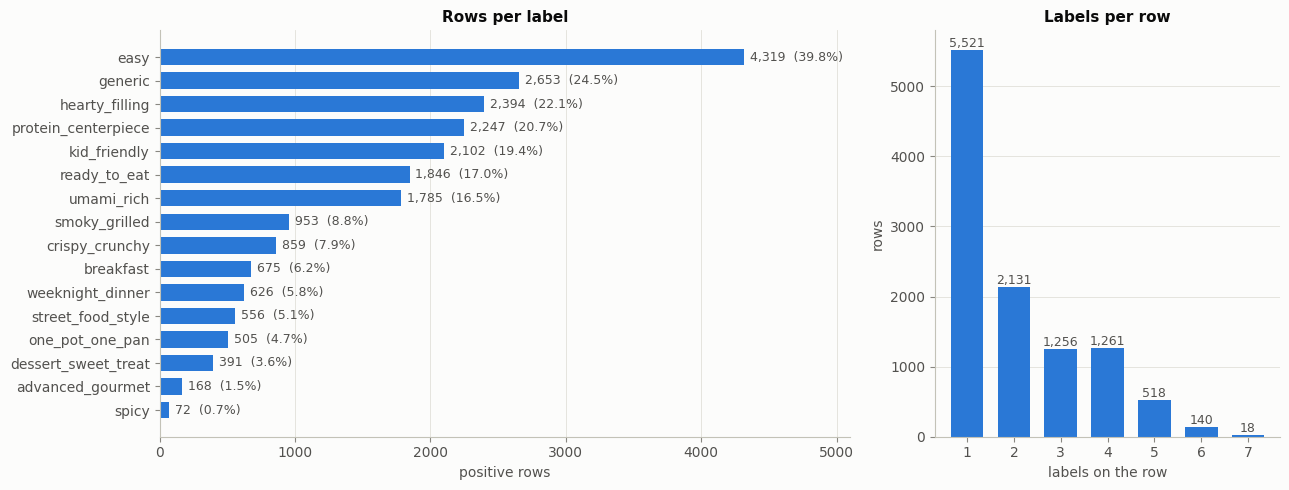

In [3]:
import matplotlib.pyplot as plt

# chart chrome (reference palette: light surface, recessive axes, categorical slots in fixed order)
SURFACE, INK, INK_2, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
SERIES = ["#2a78d6", "#eb6834"]
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": INK_2, "axes.titlecolor": INK, "axes.titlesize": 11, "axes.titleweight": "bold",
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False, "legend.frameon": False,
})

label_counts = Y.sum().sort_values(ascending=False)
label_balance = pd.DataFrame({
    "positives": label_counts,
    "prevalence_%": (100 * label_counts / len(Y)).round(2),
    "imbalance_vs_max": (label_counts.max() / label_counts).round(1),
})
labels_per_row = Y.sum(axis=1)
print(f"rows {len(Y)}, labels/row mean {labels_per_row.mean():.2f}, "
      f"max imbalance {label_balance['imbalance_vs_max'].max():.0f}:1 "
      f"({label_counts.index[0]} vs {label_counts.index[-1]})")
display(label_balance)

fig, (ax_bal, ax_card) = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [2, 1]})
order = label_counts.sort_values()
bars = ax_bal.barh(order.index, order.values, color=SERIES[0], height=0.7)
for bar, (name, cnt) in zip(bars, order.items()):
    ax_bal.text(bar.get_width() + label_counts.max() * 0.01, bar.get_y() + bar.get_height() / 2,
                f"{cnt:,}  ({100 * cnt / len(Y):.1f}%)", va="center", fontsize=9, color=INK_2)
ax_bal.set_xlim(0, label_counts.max() * 1.18)
ax_bal.grid(axis="y", visible=False)
ax_bal.set_xlabel("positive rows")
ax_bal.set_title("Rows per label")

card = labels_per_row.value_counts().sort_index()
ax_card.bar(card.index.astype(str), card.values, color=SERIES[0], width=0.7)
for x, v in zip(card.index.astype(str), card.values):
    ax_card.text(x, v, f"{v:,}", ha="center", va="bottom", fontsize=9, color=INK_2)
ax_card.grid(axis="x", visible=False)
ax_card.set_xlabel("labels on the row")
ax_card.set_ylabel("rows")
ax_card.set_title("Labels per row")
fig.tight_layout()
plt.show()

## Generic gate + classifier chain over attention embeddings + nutrient UMAP

```text
product / adj / verb terms ──MiniLM (frozen)──► self-attention within each item ──pool──► EMB_DIM vector ─┐
nutrients ──log1p──► StandardScaler ──► UMAP (NUTRIENT_UMAP_COMPONENTS) ───────────────────────────────────┴─► concat ─┐
                                                                                                                         ▼
                                                    generic gate (LogisticRegression, generic vs not) ──generic──► {generic}, stop
                                                                         │ not generic
                                                                         ▼
                                                    ClassifierChain(LogisticRegression) over the 15 specific labels
```

- `generic` (~24% of rows) is exclusive, so it is not a chain link: a binary gate decides generic vs not, and only
  non-generic rows reach the chain. The chain is trained on non-generic train rows only. A row the gate sends to the chain
  always gets at least one label (its most likely one, if no chain link fires).

- Each item is its own attention sequence (padding is masked), so terms only attend to terms of the same item.
  A learned type embedding marks each term as product, adj or verb.
- The encoder is trained on the train-split labels (multi-label BCE head), then its pooled vectors are the item embeddings.
  One encoder embeds every row: out-of-fold encoders would each learn their own embedding space, which the chain cannot
  combine. Encoder, scaler, UMAP and chain are fit on the train split only.
- Rare labels (e.g. `spicy`, 72 rows) are handled by `class_weight="balanced"` in each chain link and `pos_weight` in the encoder loss.
- Caveat: the silver labels were produced by rules over the same description/product/adj/verb text and nutrient thresholds,
  so these scores measure how well the rules are recovered, not true label quality.

In [4]:
import ast
import os
import random

import numpy as np
import torch
import umap
from joblib.externals.loky import ProcessPoolExecutor
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, hamming_loss, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.multioutput import ClassifierChain
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.nn import functional as F

RANDOM_STATE = 42
TEST_SIZE = 0.2
TERM_MODEL = "sentence-transformers/all-MiniLM-L6-v2"  # Frozen vector per product / adj / verb term.
TERM_REVISION = "1110a243fdf4706b3f48f1d95db1a4f5529b4d41"
TOKEN_TYPES = ["product", "adj", "verb"]
EMB_DIM = 64
ATTENTION_HEADS = 4
ENCODER_EPOCHS = 20
ENCODER_BATCH_SIZE = 256
ENCODER_LR = 1e-3
MAX_POS_WEIGHT = 50.0
NUTRIENT_COLS = ["protein_g", "fat_g", "carb_g", "energy_kcal", "fiber_g", "sodium_mg",
                 "cholesterol_mg", "satfat_g", "sugars_g"]
NUTRIENT_UMAP_COMPONENTS = 6
NUTRIENT_UMAP_NEIGHBORS = 15
NUTRIENT_UMAP_MIN_DIST = 0.0  # tight clusters: better as model features than for looks

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

In [5]:
# ---------- terms per item ----------
def parse_terms(col):
    return recipe_classes_df[col].fillna("[]").apply(ast.literal_eval).apply(
        lambda xs: [str(x).strip().lower() for x in xs if str(x).strip()])

item_terms = []  # per item: list of (term, type index)
for row in zip(*(parse_terms(c) for c in TOKEN_TYPES)):
    item_terms.append([(t, k) for k, terms in enumerate(row) for t in terms])

vocab = sorted({t for terms in item_terms for t, _ in terms})
term_index = {t: i + 1 for i, t in enumerate(vocab)}  # 0 = padding
term_model = SentenceTransformer(TERM_MODEL, revision=TERM_REVISION, device="cpu")
term_vectors = term_model.encode(vocab, batch_size=256, normalize_embeddings=True, show_progress_bar=False)
term_vectors = np.vstack([np.zeros((1, term_vectors.shape[1]), dtype=np.float32), term_vectors])

max_len = max(len(terms) for terms in item_terms)
term_ids = np.zeros((len(item_terms), max_len), dtype=np.int64)
type_ids = np.zeros((len(item_terms), max_len), dtype=np.int64)
for i, terms in enumerate(item_terms):
    for j, (t, k) in enumerate(terms):
        term_ids[i, j] = term_index[t]
        type_ids[i, j] = k
assert (term_ids[:, 0] > 0).all()  # every item has at least one term
print(f"{len(vocab)} terms, max {max_len} per item")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

2977 terms, max 14 per item


In [6]:
class ItemAttentionEncoder(nn.Module):
    """Self-attention over one item's product/adj/verb terms, masked-mean pooled to EMB_DIM."""

    def __init__(self, term_vectors, n_labels):
        super().__init__()
        self.term_emb = nn.Embedding.from_pretrained(torch.tensor(term_vectors), freeze=True, padding_idx=0)
        self.proj = nn.Linear(term_vectors.shape[1], EMB_DIM)
        self.type_emb = nn.Embedding(len(TOKEN_TYPES), EMB_DIM)
        self.attn = nn.MultiheadAttention(EMB_DIM, ATTENTION_HEADS, dropout=0.1, batch_first=True)
        self.norm1 = nn.LayerNorm(EMB_DIM)
        self.ff = nn.Sequential(nn.Linear(EMB_DIM, 2 * EMB_DIM), nn.GELU(), nn.Linear(2 * EMB_DIM, EMB_DIM))
        self.norm2 = nn.LayerNorm(EMB_DIM)
        self.head = nn.Linear(EMB_DIM, n_labels)

    def embed(self, term_ids, type_ids):
        pad = term_ids == 0
        x = self.proj(self.term_emb(term_ids)) + self.type_emb(type_ids)
        a, _ = self.attn(x, x, x, key_padding_mask=pad)  # a term only sees terms of its own item
        x = self.norm1(x + a)
        x = self.norm2(x + self.ff(x))
        keep = (~pad).unsqueeze(-1).float()
        return (x * keep).sum(1) / keep.sum(1)

    def forward(self, term_ids, type_ids):
        return self.head(self.embed(term_ids, type_ids))


@torch.no_grad()
def encoder_loss(model, idx, Y_np, pos_weight):
    """Weighted BCE of the encoder's label head on rows `idx` (eval mode, so no dropout)."""
    logits = model(torch.tensor(term_ids[idx]), torch.tensor(type_ids[idx]))
    return F.binary_cross_entropy_with_logits(
        logits, torch.tensor(Y_np[idx], dtype=torch.float32), pos_weight=pos_weight).item()


def fit_encoder(idx, Y_np, eval_idx=None):
    """Train on rows `idx`; after every epoch print and record the weighted BCE on `idx` and on `eval_idx`."""
    model = ItemAttentionEncoder(term_vectors, Y_np.shape[1])
    y = torch.tensor(Y_np[idx], dtype=torch.float32)
    pos = y.sum(0)
    pos_weight = ((len(y) - pos) / pos.clamp(min=1)).clamp(max=MAX_POS_WEIGHT)
    terms, types = torch.tensor(term_ids[idx]), torch.tensor(type_ids[idx])
    opt = torch.optim.AdamW(model.parameters(), lr=ENCODER_LR, weight_decay=1e-4)
    history = []
    for epoch in range(ENCODER_EPOCHS):
        model.train()
        perm = torch.randperm(len(idx))
        for b in range(0, len(idx), ENCODER_BATCH_SIZE):
            bi = perm[b:b + ENCODER_BATCH_SIZE]
            loss = F.binary_cross_entropy_with_logits(model(terms[bi], types[bi]), y[bi], pos_weight=pos_weight)
            opt.zero_grad()
            loss.backward()
            opt.step()
        model.eval()
        row = {"epoch": epoch + 1, "train loss": encoder_loss(model, idx, Y_np, pos_weight)}
        if eval_idx is not None:
            row["validation loss"] = encoder_loss(model, eval_idx, Y_np, pos_weight)
        history.append(row)
        print(f"epoch {epoch + 1:>2}/{ENCODER_EPOCHS}  " + "  ".join(f"{k} {v:.4f}" for k, v in row.items() if k != "epoch"))
    return model, pd.DataFrame(history).set_index("epoch")


@torch.no_grad()
def encode(model, idx):
    return model.embed(torch.tensor(term_ids[idx]), torch.tensor(type_ids[idx])).numpy()

In [7]:
# ---------- split + item embeddings ----------
Y_np = Y[LABEL_COLS].to_numpy()
train_idx, test_idx = train_test_split(np.arange(len(Y_np)), test_size=TEST_SIZE, random_state=RANDOM_STATE)

encoder, encoder_history = fit_encoder(train_idx, Y_np, eval_idx=test_idx)
item_emb = encode(encoder, np.arange(len(Y_np)))

epoch  1/20  train loss 1.0688  validation loss 1.0740


epoch  2/20  train loss 0.9519  validation loss 0.9666


epoch  3/20  train loss 0.6891  validation loss 0.7007


epoch  4/20  train loss 0.5991  validation loss 0.6166


epoch  5/20  train loss 0.5272  validation loss 0.5595


...

epoch 16/20  train loss 0.3114  validation loss 0.3903


epoch 17/20  train loss 0.3017  validation loss 0.3858


epoch 18/20  train loss 0.2940  validation loss 0.3805


epoch 19/20  train loss 0.2931  validation loss 0.3674


epoch 20/20  train loss 0.2797  validation loss 0.3787


### Encoder training curve

Weighted BCE of the encoder's label head (the loss it is trained on, `pos_weight` = negatives / positives per label,
capped at `MAX_POS_WEIGHT`) after every epoch, on the train rows and on the held-out rows (`test_idx`, the validation
split). The held-out rows are only watched, never trained on.


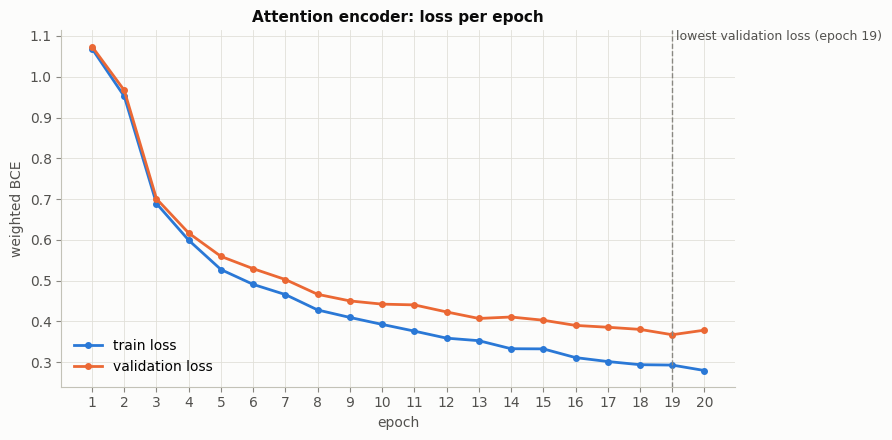

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for col, color in zip(["train loss", "validation loss"], SERIES):
    ax.plot(encoder_history.index, encoder_history[col], color=color, lw=2, marker="o", ms=4, label=col)
best_epoch = encoder_history["validation loss"].idxmin()
ax.axvline(best_epoch, color=MUTED, lw=1, ls="--")
ax.text(best_epoch, ax.get_ylim()[1], f" lowest validation loss (epoch {best_epoch})", va="top", fontsize=9, color=INK_2)
ax.set_xticks(encoder_history.index)
ax.set_xlabel("epoch")
ax.set_ylabel("weighted BCE")
ax.set_title("Attention encoder: loss per epoch")
ax.legend()
fig.tight_layout()
plt.show()


In [9]:
# ---------- label balance across the split: rare labels must still have test positives ----------
split_balance = pd.DataFrame({
    "train_%": (100 * Y_np[train_idx].mean(0)).round(2),
    "test_%": (100 * Y_np[test_idx].mean(0)).round(2),
    "test_positives": Y_np[test_idx].sum(0),
}, index=LABEL_COLS).sort_values("test_positives")
split_balance["diff_pp"] = (split_balance["test_%"] - split_balance["train_%"]).round(2)
display(split_balance)

,train_%,test_%,test_positives,diff_pp
spicy,0.66,0.69,15,0.03
advanced_gourmet,1.45,1.94,42,0.49
dessert_sweet_treat,3.65,3.41,74,-0.24
street_food_style,5.23,4.70,102,-0.53
one_pot_one_pan,4.60,4.89,106,0.29
weeknight_dinner,5.83,5.53,120,-0.30
breakfast,6.28,5.99,130,-0.29
crispy_crunchy,7.92,7.93,172,0.01
smoky_grilled,8.83,8.62,187,-0.21
umami_rich,16.49,16.32,354,-0.17


In [10]:
# ---------- nutrients: log1p (heavy right tail, e.g. sodium up to 38,758 mg) → standardize → UMAP ----------
nutrients = np.log1p(recipe_classes_df[NUTRIENT_COLS].clip(lower=0))
nutrients = nutrients.fillna(nutrients.iloc[train_idx].median()).to_numpy()

nutrient_scaler = StandardScaler().fit(nutrients[train_idx])
nutrient_umap = umap.UMAP(
    n_components=NUTRIENT_UMAP_COMPONENTS, n_neighbors=NUTRIENT_UMAP_NEIGHBORS, min_dist=NUTRIENT_UMAP_MIN_DIST,
    random_state=RANDOM_STATE,
).fit(nutrient_scaler.transform(nutrients[train_idx]))


def umap_transform_rows(reducer, rows):
    return np.vstack([reducer.transform(row[None]) for row in rows])


def umap_transform(reducer, rows):
    """Transform each row on its own (batch transform depends on the other rows in the call), over all cores.
    A separate process pool, so the reusable XGBoost worker is left alone."""
    chunks = np.array_split(rows, min(len(rows), 4 * os.cpu_count()))
    with ProcessPoolExecutor(max_workers=os.cpu_count()) as pool:
        return np.vstack(list(pool.map(umap_transform_rows, [reducer] * len(chunks), chunks)))


nutrient_umap_comps = umap_transform(nutrient_umap, nutrient_scaler.transform(nutrients))
print(f"nutrient UMAP: {nutrient_umap_comps.shape[1]} components")


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


nutrient UMAP: 6 components


## Nutrient variance before / after standardization

Raw nutrients sit on very different scales (sodium in mg vs fiber in g), so without scaling UMAP's distances would just follow sodium.
log1p tames the right tail; `StandardScaler` then gives every nutrient mean 0 / variance 1 on the train rows.

,raw_var,log1p_var,standardized_var,standardized_mean,raw_share_%
protein_g,102.2,1.084,1.000,1.5e-16,0.01
fat_g,235.8,1.301,1.000,1.9e-15,0.03
carb_g,551.9,2.207,1.000,8.1e-15,0.07
energy_kcal,"26,189.0",0.981,1.000,-1.1e-14,3.41
fiber_g,13.6,0.559,1.000,-8.3e-15,0.00
sodium_mg,"727,226.3",3.073,1.000,1.1e-14,94.76
cholesterol_mg,"12,951.3",3.969,1.000,-4.0e-15,1.69
satfat_g,35.4,0.706,1.000,-6.7e-16,0.00
sugars_g,147.7,1.171,1.000,4.4e-15,0.02


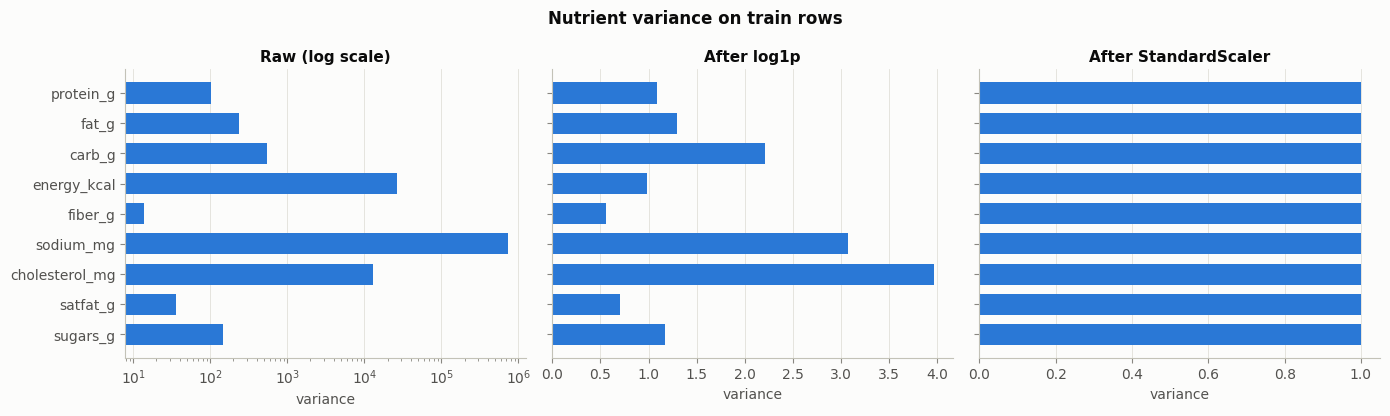

In [11]:
nutrients_raw = recipe_classes_df[NUTRIENT_COLS].iloc[train_idx]
nutrients_log = nutrients[train_idx]                    # after log1p + median fill
nutrients_std = nutrient_scaler.transform(nutrients_log)  # after StandardScaler

nutrient_variance = pd.DataFrame({
    "raw_var": nutrients_raw.var(ddof=0),
    "log1p_var": nutrients_log.var(0),
    "standardized_var": nutrients_std.var(0),
    "standardized_mean": nutrients_std.mean(0),
}, index=NUTRIENT_COLS)
nutrient_variance["raw_share_%"] = 100 * nutrient_variance["raw_var"] / nutrient_variance["raw_var"].sum()
display(nutrient_variance.style.format({
    "raw_var": "{:,.1f}", "log1p_var": "{:.3f}", "standardized_var": "{:.3f}",
    "standardized_mean": "{:.1e}", "raw_share_%": "{:.2f}"}))
assert np.allclose(nutrients_std.var(0), 1, atol=1e-6) and np.allclose(nutrients_std.mean(0), 0, atol=1e-6)

# one panel per stage: the stages differ by orders of magnitude, so they never share an axis
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), sharey=True)
stages = [("raw_var", "Raw (log scale)"), ("log1p_var", "After log1p"), ("standardized_var", "After StandardScaler")]
for ax, (col, title) in zip(axes, stages):
    ax.barh(NUTRIENT_COLS, nutrient_variance[col], color=SERIES[0], height=0.7)
    ax.set_title(title)
    ax.set_xlabel("variance")
    ax.grid(axis="y", visible=False)
axes[0].set_xscale("log")
axes[0].invert_yaxis()
fig.suptitle("Nutrient variance on train rows", color=INK, fontweight="bold")
fig.tight_layout()
plt.show()

## Nutrient UMAP

The standardized nutrients are reduced to `NUTRIENT_UMAP_COMPONENTS` UMAP components (fit on train rows). UMAP is
non-linear and keeps local neighbourhoods rather than variance, so the components have no explained-variance ratio or
loadings. `random_state` makes it deterministic but single-threaded.

UMAP's batch `transform` is **not per-row**: a row's coordinates depend on which other rows are in the same call (up
to ~2.4 units here), so a saved model could not reproduce them for new items. Every row is therefore transformed on
its own (`umap_transform`, split over all CPU cores), which gives the same coordinates for a row however it is
batched. Inference must do the same.

The plot shows the first two components on a 4,000-row sample, colored by generic vs labelled items.


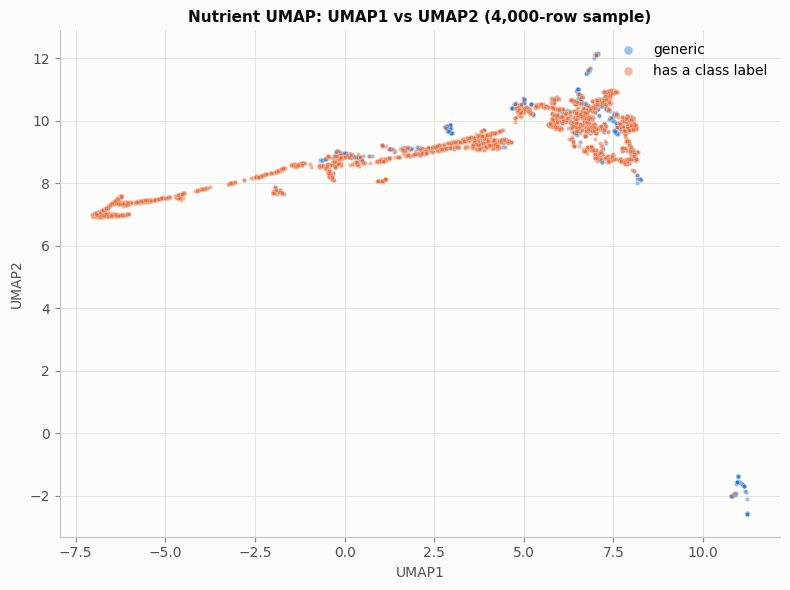

In [12]:
rng = np.random.default_rng(RANDOM_STATE)
sample = rng.choice(len(nutrient_umap_comps), size=min(4000, len(nutrient_umap_comps)), replace=False)
is_generic = Y["generic"].to_numpy()[sample] == 1

fig, ax = plt.subplots(figsize=(8, 6))
for mask, name, color in [(is_generic, "generic", SERIES[0]), (~is_generic, "has a class label", SERIES[1])]:
    ax.scatter(nutrient_umap_comps[sample][mask, 0], nutrient_umap_comps[sample][mask, 1], s=10, alpha=0.45,
               color=color, edgecolors=SURFACE, linewidths=0.3, label=name)
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.legend(markerscale=2)
ax.set_title("Nutrient UMAP: UMAP1 vs UMAP2 (4,000-row sample)")
fig.tight_layout()
plt.show()


In [13]:
# ---------- concat features; label layout of the gate + chain ----------
X = np.hstack([item_emb, nutrient_umap_comps])
feature_scaler = StandardScaler().fit(X[train_idx])
X = feature_scaler.transform(X)

GENERIC = LABEL_COLS.index("generic")
CHAIN_LABELS = [c for c in LABEL_COLS if c != "generic"]
chain_cols = [LABEL_COLS.index(c) for c in CHAIN_LABELS]

# the chain is trained on non-generic rows only
specific_train_idx = train_idx[Y_np[train_idx, GENERIC] == 0]
Y_specific = Y_np[np.ix_(specific_train_idx, chain_cols)]
chain_order = np.argsort(-Y_specific.sum(0))  # most frequent label first


def predict_labels(X_rows, gate, chain):
    """Gate first: generic rows get only `generic`; the rest get the chain's labels (at least one)."""
    out = np.zeros((len(X_rows), len(LABEL_COLS)), dtype=int)
    gated_generic = gate.predict(X_rows).astype(bool)
    out[gated_generic, GENERIC] = 1
    specific_rows = np.flatnonzero(~gated_generic)
    if len(specific_rows):
        pred = chain.predict(X_rows[specific_rows]).astype(int)
        empty = pred.sum(1) == 0
        if empty.any():
            pred[empty, chain.predict_proba(X_rows[specific_rows[empty]]).argmax(1)] = 1
        out[np.ix_(specific_rows, chain_cols)] = pred
    return out


Y_true = Y_np[test_idx]


generic gate: accuracy 0.873  F1 0.774
chain on true non-generic rows: micro F1 0.838  macro F1 0.783
end to end:
X: (10845, 70)  (item embedding 64 + nutrient UMAP 6)
micro F1 0.808  macro F1 0.752  hamming loss 0.052  exact match 0.571
                     precision    recall  f1-score   support

   advanced_gourmet       0.36      0.52      0.43        42
          breakfast       0.76      0.89      0.82       130
     crispy_crunchy       0.66      0.83      0.73       172
dessert_sweet_treat       0.64      0.84      0.73        74
               easy       0.88      0.87      0.88       853
            generic       0.69      0.89      0.77       533
     hearty_filling       0.80      0.89      0.84       471
       kid_friendly       0.79      0.83      0.81       398
    one_pot_one_pan       0.51      0.78      0.62       106
protein_centerpiece       0.90      0.98      0.93       452
       ready_to_eat       0.81      0.83      0.82       359
      smoky_grilled       0.9

## Model comparison: setup

Every model below uses the same features `X` (item embedding + nutrient UMAP components), the same train/test split and the same
16 labels as the main logistic-regression model. Each model follows the same pipeline:
a binary `generic` gate, then a classifier chain over the 15 specific labels trained on non-generic rows
(`predict_labels`). The same estimator type is used for the gate and every chain link. Results go into `model_results`
for the comparison section at the end.

**Validation and loss.** The held-out 20% split (`test_idx`) is the validation split below; no model is fitted on it.
The loss is weighted binary cross-entropy averaged over the labels, with positives weighted by negatives / positives of
each label on the train rows (capped at `MAX_POS_WEIGHT`, as in the encoder). The pipeline's probability for `generic`
is the gate's; for a specific label it is P(not generic) × the chain's probability. **Accuracy** is exact-match
accuracy (every label of the row right); **label accuracy** is the share of correct label cells (1 − hamming loss).

**Epochs.** Iterative models show the loss after every training step on train and validation rows: logistic regression
per lbfgs iteration, XGBoost per boosting round, Random Forest per tree (the encoder per epoch, above). The gate is
scored on all rows, the chain links on non-generic rows with the true earlier labels as extra inputs (as in training),
averaged over links. KNN, the decision tree and the SVM are fitted in one pass, so they have no epochs. Every model
section ends with its train / validation loss and accuracy.

In [15]:
# Run once if xgboost is missing, then restart the kernel.
# %pip install xgboost
import time
import warnings
from types import SimpleNamespace

from joblib.externals.loky import get_reusable_executor
from scipy.special import expit
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import precision_score, recall_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

model_results = {}  # model name -> train / validation predictions, probabilities, fit time, settings
executor = get_reusable_executor(max_workers=1)  # torch-free worker for XGBoost (see the XGBoost section)

# L2 strength per model (LR / SVM: C, smaller = stronger; XGBoost: reg_lambda, larger = stronger),
# set in the L2 regularization section
L2_STRENGTH = {"Logistic regression": 1.0, "SVM": 1.0, "XGBoost": 1.0}

# one factory per model type: the same estimator is the generic gate and every chain link
MODEL_FACTORIES = {
    "Logistic regression": lambda: LogisticRegression(C=L2_STRENGTH["Logistic regression"], class_weight="balanced",
                                                      max_iter=2000),
    "KNN": lambda: KNeighborsClassifier(n_neighbors=15, weights="distance"),
    "Decision Tree": lambda: DecisionTreeClassifier(class_weight="balanced", min_samples_leaf=5,
                                                    random_state=RANDOM_STATE),
    "SVM": lambda: SVC(C=L2_STRENGTH["SVM"], kernel="rbf", class_weight="balanced", probability=True,
                       random_state=RANDOM_STATE),
    "XGBoost": lambda: BalancedXGB(reg_lambda=L2_STRENGTH["XGBoost"]),
    "Random Forest": lambda: RandomForestClassifier(n_estimators=300, class_weight="balanced_subsample",
                                                    min_samples_leaf=2, n_jobs=-1, random_state=RANDOM_STATE),
}
LABEL_POS_WEIGHT = np.minimum((len(train_idx) - Y_np[train_idx].sum(0)) / np.maximum(Y_np[train_idx].sum(0), 1),
                              MAX_POS_WEIGHT)


def weighted_bce(Y, P, pos_weight):
    """Per-label binary cross-entropy with positives weighted by `pos_weight`, averaged over rows."""
    P = np.clip(P, 1e-7, 1 - 1e-7)
    return -(pos_weight * Y * np.log(P) + (1 - Y) * np.log(1 - P)).mean(0)


class EnsembleChain:
    """Several fitted chains with different orders: probabilities averaged, labels at 0.5."""

    def __init__(self, chains):
        self.chains = chains

    def predict_proba(self, X):
        return np.mean([c.predict_proba(X) for c in self.chains], axis=0)

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)


def pipeline_proba(X_rows, gate, chain):
    """Label probabilities of the gated pipeline: P(generic) from the gate, each specific label
    P(not generic) × the chain's probability."""
    proba = np.zeros((len(X_rows), len(LABEL_COLS)))
    proba[:, GENERIC] = gate.predict_proba(X_rows)[:, 1]
    proba[:, chain_cols] = (1 - proba[:, [GENERIC]]) * chain.predict_proba(X_rows)
    return proba


def bootstrap_rows(n, i):
    """Row indices of bootstrap sample `i` (n rows drawn with replacement, seeded per chain)."""
    return np.random.default_rng(RANDOM_STATE + i).choice(n, size=n, replace=True)


def fit_pipeline(model_name, X_fit, y_gate, X_specific, Y_specific, orders, gate=None, bootstrap=False):
    """Fit the generic gate (unless a fitted `gate` is given) and one chain per order, all of `model_name`.
    With `bootstrap`, chain i is fit on its own bootstrap sample of the rows (bagging, as in ECC)."""
    make = MODEL_FACTORIES[model_name]
    if gate is None:
        gate = make().fit(X_fit, y_gate)
    chains = []
    for i, o in enumerate(orders):
        rows = bootstrap_rows(len(X_specific), i) if bootstrap else slice(None)
        chains.append(ClassifierChain(make(), order=o, random_state=RANDOM_STATE).fit(X_specific[rows], Y_specific[rows]))
    return gate, chains


def fit_evaluate_pipeline(model_name, Xf, orders, gate=None, curves=None, bootstrap=False):
    """Fit on the train rows of features `Xf`, then predict train and validation rows.
    `curves=(staged_probas, steps)` also records the loss per training step."""
    start = time.perf_counter()
    gate, chains = fit_pipeline(model_name, Xf[train_idx], Y_np[train_idx, GENERIC], Xf[specific_train_idx],
                                Y_specific, orders, gate, bootstrap)
    fit_seconds = time.perf_counter() - start
    chain = chains[0] if len(chains) == 1 else EnsembleChain(chains)
    out = {"fit_seconds": fit_seconds,
           "train_pred": predict_labels(Xf[train_idx], gate, chain), "train_proba": pipeline_proba(Xf[train_idx], gate, chain),
           "pred": predict_labels(Xf[test_idx], gate, chain), "proba": pipeline_proba(Xf[test_idx], gate, chain)}
    if curves is not None:
        out["curves"] = chain_loss_curves(gate, chain, *curves, Xf)
    return out, gate, chain


def fit_evaluate_in_worker(*args):
    """XGBoost runs in the torch-free worker: only results come back, the fitted models stay there."""
    return fit_evaluate_pipeline(*args)[0]


def summary_scores(r):
    """Train / validation loss (weighted BCE, mean over labels), accuracy and macro precision / recall / F1."""
    Y_train = Y_np[train_idx]
    return {
        "train loss": weighted_bce(Y_train, r["train_proba"], LABEL_POS_WEIGHT).mean(),
        "validation loss": weighted_bce(Y_true, r["proba"], LABEL_POS_WEIGHT).mean(),
        "train accuracy": accuracy_score(Y_train, r["train_pred"]),
        "validation accuracy": accuracy_score(Y_true, r["pred"]),
        "validation label accuracy": 1 - hamming_loss(Y_true, r["pred"]),
        "macro precision": precision_score(Y_true, r["pred"], average="macro", zero_division=0),
        "macro recall": recall_score(Y_true, r["pred"], average="macro", zero_division=0),
        "macro F1": f1_score(Y_true, r["pred"], average="macro", zero_division=0),
    }


def show_model_summary(results, names=None):
    """End-of-section table: train / validation loss and accuracy of the given models."""
    table = pd.DataFrame({name: summary_scores(results[name]) for name in (names or results)}).T
    display(table.style.format("{:.3f}")
            .background_gradient(cmap="Greens_r", subset=["validation loss"])
            .background_gradient(cmap="Greens", subset=["validation accuracy", "macro F1"]))
    return table


def record_result(name, out, results, spec):
    results[name] = {**out, "spec": spec}
    s = summary_scores(results[name])
    print(f"{name}: fit {out['fit_seconds']:.1f}s  train loss {s['train loss']:.3f}  "
          f"validation loss {s['validation loss']:.3f}  accuracy {s['validation accuracy']:.3f}  "
          f"micro F1 {f1_score(Y_true, out['pred'], average='micro'):.3f}  macro F1 {s['macro F1']:.3f}")
    print(classification_report(Y_true, out["pred"], target_names=LABEL_COLS, zero_division=0))


def run_pipeline(name, model_name, results, gate="own", orders=None, curves=None, bootstrap=False):
    """Fit `model_name` as the generic gate (gate="own") or behind the shared LR gate (gate="lr"), and as the chain
    over the specific labels (one chain per order, averaged if several; `bootstrap` bags the chains);
    record train / validation results.
    Returns (gate, chain), or (None, None) for XGBoost, whose models stay in the worker."""
    orders = [chain_order] if orders is None else orders
    args = (model_name, X, orders, None if gate == "own" else generic_gate, curves, bootstrap)
    if model_name == "XGBoost":
        out, fitted_gate, fitted_chain = executor.submit(fit_evaluate_in_worker, *args).result(), None, None
    else:
        out, fitted_gate, fitted_chain = fit_evaluate_pipeline(*args)
    record_result(name, out, results,
                  {"model": model_name, "gate": gate, "orders": [np.asarray(o) for o in orders],
                   "bootstrap": bootstrap})
    return fitted_gate, fitted_chain


# ---------- loss per training step ----------
def chain_loss_curves(gate, chain, staged_probas, steps, Xf):
    """Weighted BCE after each training step for the gate (all rows) and the chain (non-generic rows, true earlier
    labels as extra inputs, mean over links), on train and validation rows.
    `staged_probas(model, X, steps)` returns the positive-class probability after each step."""
    specific_test_idx = test_idx[Y_np[test_idx, GENERIC] == 0]
    curves = {}
    for split, rows in [("train", train_idx), ("validation", test_idx)]:
        y = Y_np[rows, GENERIC]
        curves[f"gate {split}"] = [weighted_bce(y, p, LABEL_POS_WEIGHT[GENERIC])
                                   for p in staged_probas(gate, Xf[rows], steps)]
    for split, rows in [("train", specific_train_idx), ("validation", specific_test_idx)]:
        Y_rows = Y_np[np.ix_(rows, chain_cols)]
        link_losses = []
        for position, link in enumerate(chain.estimators_):
            j = chain.order_[position]
            X_link = np.hstack([Xf[rows], Y_rows[:, chain.order_[:position]]])
            link_losses.append([weighted_bce(Y_rows[:, j], p, LABEL_POS_WEIGHT[chain_cols[j]])
                                for p in staged_probas(link, X_link, steps)])
        curves[f"chain {split}"] = np.mean(link_losses, axis=0)
    return pd.DataFrame(curves, index=pd.Index(steps, name="step"))


def show_loss_curves(curves, model_name, step_name):
    """Per-step loss table and train / validation curves for the gate and the chain."""
    display(curves.rename_axis(step_name).style.format("{:.4f}"))
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    for ax, part in zip(axes, ["gate", "chain"]):
        for split, color in zip(["train", "validation"], SERIES):
            ax.plot(curves.index, curves[f"{part} {split}"], color=color, lw=2, label=split)
        ax.set_xlabel(step_name)
        ax.set_ylabel("weighted BCE")
        ax.set_title(f"{model_name}: {part} loss per {step_name}")
        ax.legend()
    fig.tight_layout()
    plt.show()


def lr_iteration_snapshots(estimator, X_rows, y, steps):
    """Refit `estimator` with warm starts one lbfgs iteration at a time; keep the weights after each step."""
    model = clone(estimator).set_params(warm_start=True, max_iter=1)
    snapshots, done = [], 0
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", ConvergenceWarning)
        for k in steps:
            for _ in range(k - done):
                model.fit(X_rows, y)
            done = k
            snapshots.append((model.coef_.ravel().copy(), model.intercept_[0]))
    return SimpleNamespace(snapshots_=snapshots)


def lr_curve_models(estimator, steps, Xf):
    """Snapshot models of the LR gate and chain links, trained on the same rows and features as the real ones."""
    gate = lr_iteration_snapshots(estimator, Xf[train_idx], Y_np[train_idx, GENERIC], steps)
    links = [lr_iteration_snapshots(estimator, np.hstack([Xf[specific_train_idx], Y_specific[:, chain_order[:position]]]),
                                    Y_specific[:, j], steps)
             for position, j in enumerate(chain_order)]
    return gate, SimpleNamespace(estimators_=links, order_=np.asarray(chain_order))


def lr_staged_probas(model, X_rows, steps):
    return [expit(X_rows @ w + b) for w, b in model.snapshots_]


def rf_staged_probas(model, X_rows, steps):
    """Forest probability using only its first k trees, for each k in `steps`."""
    cumulative = np.cumsum([tree.predict_proba(X_rows)[:, 1] for tree in model.estimators_], axis=0)
    return [cumulative[k - 1] / k for k in steps]


class BalancedXGB(ClassifierMixin, BaseEstimator):
    """XGBClassifier whose scale_pos_weight is set from the labels it is fitted on, with L2 on the leaf weights
    (reg_lambda) and early stopping: a stratified share of the rows is held out, training stops once their weighted
    log loss has not improved for `early_stopping_rounds`, then the model is refit on all rows with that many rounds."""

    def __init__(self, n_estimators=300, max_depth=4, learning_rate=0.1, reg_lambda=1.0, early_stopping_rounds=30,
                 validation_fraction=0.15):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.learning_rate = learning_rate
        self.reg_lambda = reg_lambda
        self.early_stopping_rounds = early_stopping_rounds
        self.validation_fraction = validation_fraction

    def _xgb(self, n_estimators, scale_pos_weight, **kwargs):
        return XGBClassifier(n_estimators=n_estimators, max_depth=self.max_depth, learning_rate=self.learning_rate,
                             reg_lambda=self.reg_lambda, scale_pos_weight=scale_pos_weight, eval_metric="logloss",
                             n_jobs=4, random_state=RANDOM_STATE, **kwargs)

    def fit(self, X, y):
        pos = int(np.sum(y))
        scale_pos_weight = (len(y) - pos) / max(pos, 1)
        self.best_n_estimators_ = self.n_estimators
        if self.early_stopping_rounds:
            X_fit, X_stop, y_fit, y_stop = train_test_split(
                X, y, test_size=self.validation_fraction, random_state=RANDOM_STATE,
                stratify=y if min(pos, len(y) - pos) >= 2 else None)
            # positives weighted as in training, so the stopping loss is the same weighted BCE
            probe = self._xgb(self.n_estimators, scale_pos_weight, early_stopping_rounds=self.early_stopping_rounds).fit(
                X_fit, y_fit, eval_set=[(X_stop, y_stop)],
                sample_weight_eval_set=[np.where(y_stop == 1, scale_pos_weight, 1.0)], verbose=False)
            self.best_n_estimators_ = probe.best_iteration + 1
        self.model_ = self._xgb(self.best_n_estimators_, scale_pos_weight).fit(X, y)
        self.classes_ = self.model_.classes_
        return self

    def predict(self, X):
        return self.model_.predict(X)

    def predict_proba(self, X):
        return self.model_.predict_proba(X)


Logistic regression: fit 0.5s  train loss 0.334  validation loss 0.604  accuracy 0.571  micro F1 0.808  macro F1 0.752
                     precision    recall  f1-score   support

   advanced_gourmet       0.36      0.52      0.43        42
          breakfast       0.76      0.89      0.82       130
     crispy_crunchy       0.66      0.83      0.73       172
dessert_sweet_treat       0.64      0.84      0.73        74
               easy       0.88      0.87      0.88       853
            generic       0.69      0.89      0.77       533
     hearty_filling       0.80      0.89      0.84       471
       kid_friendly       0.79      0.83      0.81       398
    one_pot_one_pan       0.51      0.78      0.62       106
protein_centerpiece       0.90      0.98      0.93       452
       ready_to_eat       0.81      0.83      0.82       359
      smoky_grilled       0.95      0.99      0.97       187
              spicy       0.73      0.53      0.62        15
  street_food_style       

## L2 regularization

The train / validation gap shows overfitting (e.g. XGBoost train loss 0.07 vs validation 0.62 before this section was
added). Three models have an L2 penalty to tune:

- **Logistic regression:** `C` on the weights (L2 is sklearn's default penalty); smaller `C` = stronger.
- **SVM:** `C`, the same trade-off for the RBF-kernel weights; smaller = stronger.
- **XGBoost:** `reg_lambda`, L2 on the leaf weights; larger = stronger. XGBoost also stops early (see `BalancedXGB`).

Each strength is chosen by the full pipeline's weighted BCE on an **inner validation split** (20% of the train rows),
never on the held-out split. The chosen values go into `MODEL_FACTORIES`, so the main model and every section below
use them. KNN, the decision tree and the random forest have no weights to penalise (trees are limited by leaf size
instead); the encoder is not overfitting (validation loss still falling at epoch 20) and already uses AdamW weight decay.


In [ ]:
L2_GRID = {
    "Logistic regression": ("C", [1.0, 0.3, 0.1, 0.03, 0.01]),
    "SVM": ("C", [1.0, 0.3, 0.1]),
    "XGBoost": ("reg_lambda", [1.0, 5.0, 20.0, 50.0]),
}
inner_train_idx, inner_val_idx = train_test_split(train_idx, test_size=0.2, random_state=RANDOM_STATE)
inner_specific_idx = inner_train_idx[Y_np[inner_train_idx, GENERIC] == 0]


def inner_val_scores(model_name):
    """Fit gate + chain on the inner train rows; weighted BCE on inner train and inner validation rows, macro F1."""
    gate, (fitted_chain,) = fit_pipeline(model_name, X[inner_train_idx], Y_np[inner_train_idx, GENERIC],
                                         X[inner_specific_idx], Y_np[np.ix_(inner_specific_idx, chain_cols)], [chain_order])
    return {
        "train loss": weighted_bce(Y_np[inner_train_idx], pipeline_proba(X[inner_train_idx], gate, fitted_chain),
                                   LABEL_POS_WEIGHT).mean(),
        "validation loss": weighted_bce(Y_np[inner_val_idx], pipeline_proba(X[inner_val_idx], gate, fitted_chain),
                                        LABEL_POS_WEIGHT).mean(),
        "macro F1": f1_score(Y_np[inner_val_idx], predict_labels(X[inner_val_idx], gate, fitted_chain),
                             average="macro", zero_division=0),
    }


l2_rows = []
for model_name, (param, values) in L2_GRID.items():
    for value in values:
        L2_STRENGTH[model_name] = value  # read by MODEL_FACTORIES (and pickled with it for the XGBoost worker)
        start = time.perf_counter()
        scores = (executor.submit(inner_val_scores, model_name).result() if model_name == "XGBoost"
                  else inner_val_scores(model_name))
        l2_rows.append({"model": model_name, "param": param, "value": value, **scores,
                        "seconds": time.perf_counter() - start})
        print(f"{model_name} {param}={value}: train loss {scores['train loss']:.3f}  "
              f"validation loss {scores['validation loss']:.3f}  macro F1 {scores['macro F1']:.3f}")
l2_table = pd.DataFrame(l2_rows)
l2_table["gap"] = l2_table["validation loss"] - l2_table["train loss"]
for model_name, rows in l2_table.groupby("model", sort=False):
    L2_STRENGTH[model_name] = rows.loc[rows["validation loss"].idxmin(), "value"]
print("chosen:", L2_STRENGTH)
display(l2_table.set_index(["model", "param", "value"]).style.format("{:.3f}")
        .background_gradient(cmap="Greens_r", subset=["validation loss", "gap"]))

fig, axes = plt.subplots(1, len(L2_GRID), figsize=(15, 4.2))
for ax, (model_name, (param, values)) in zip(axes, L2_GRID.items()):
    rows = l2_table[l2_table["model"] == model_name]
    for col, color in zip(["train loss", "validation loss"], SERIES):
        ax.plot(rows["value"], rows[col], color=color, lw=2, marker="o", ms=5, label=col)
    ax.axvline(L2_STRENGTH[model_name], color=MUTED, lw=1, ls="--")
    ax.set_xscale("log")
    ax.set_xlabel(f"{param} ({'smaller' if param == 'C' else 'larger'} = stronger L2)")
    ax.set_ylabel("weighted BCE (inner split)")
    ax.set_title(f"{model_name}: chosen {param}={L2_STRENGTH[model_name]:g}")
    ax.legend()
fig.tight_layout()
plt.show()


In [ ]:
# ---------- main model: logistic-regression generic gate → logistic-regression classifier chain ----------
# (L2 strength C chosen in the L2 regularization section)
# stage 1: generic vs not
generic_gate = MODEL_FACTORIES["Logistic regression"]().fit(X[train_idx], Y_np[train_idx, GENERIC])

# stage 2: chain over the specific labels, trained on non-generic rows only
chain = ClassifierChain(MODEL_FACTORIES["Logistic regression"](), order=chain_order, random_state=RANDOM_STATE).fit(
    X[specific_train_idx], Y_specific)

Y_pred = predict_labels(X[test_idx], generic_gate, chain)

gate_pred = generic_gate.predict(X[test_idx])
print(f"generic gate: accuracy {accuracy_score(Y_true[:, GENERIC], gate_pred):.3f}  "
      f"F1 {f1_score(Y_true[:, GENERIC], gate_pred):.3f}")
specific_test = Y_true[:, GENERIC] == 0  # chain alone, on rows that truly are non-generic
chain_only = chain.predict(X[test_idx][specific_test]).astype(int)
print(f"chain on true non-generic rows: micro F1 {f1_score(Y_true[specific_test][:, chain_cols], chain_only, average='micro'):.3f}  "
      f"macro F1 {f1_score(Y_true[specific_test][:, chain_cols], chain_only, average='macro'):.3f}")
print("end to end:")
print(f"X: {X.shape}  (item embedding {EMB_DIM} + nutrient UMAP {nutrient_umap_comps.shape[1]})")
print(f"micro F1 {f1_score(Y_true, Y_pred, average='micro'):.3f}  "
      f"macro F1 {f1_score(Y_true, Y_pred, average='macro'):.3f}  "
      f"hamming loss {hamming_loss(Y_true, Y_pred):.3f}  "
      f"exact match {accuracy_score(Y_true, Y_pred):.3f}")
print(classification_report(Y_true, Y_pred, target_names=LABEL_COLS, zero_division=0))

## Save weights

`model_artifacts/recipe_classifier/`:
- `recipe_classifier.pt`: attention encoder `state_dict`, term vocabulary + frozen MiniLM term vectors, encoder config.
- `preprocessing.joblib`: nutrient train medians, nutrient scaler, UMAP (transform one row at a time, see above), feature scaler, generic gate, classifier chain.
- `config.json`: label order, dropped labels, settings and test metrics.

The last lines reload the files and check they reproduce the test predictions.

In [14]:
import json
from pathlib import Path

import joblib

ARTIFACT_DIR = Path("model_artifacts/recipe_classifier")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

encoder_config = {"emb_dim": EMB_DIM, "attention_heads": ATTENTION_HEADS, "token_types": TOKEN_TYPES,
                  "max_len": max_len, "n_labels": len(LABEL_COLS)}
torch.save({"state_dict": {k: v.detach().cpu() for k, v in encoder.state_dict().items()},
            "encoder_config": encoder_config, "vocab": vocab, "term_vectors": term_vectors},
           ARTIFACT_DIR / "recipe_classifier.pt")
joblib.dump({"nutrient_cols": NUTRIENT_COLS,
             "nutrient_medians": np.log1p(recipe_classes_df[NUTRIENT_COLS].clip(lower=0)).iloc[train_idx].median(),
             "nutrient_scaler": nutrient_scaler, "nutrient_umap": nutrient_umap,
             "feature_scaler": feature_scaler, "generic_gate": generic_gate, "chain": chain},
            ARTIFACT_DIR / "preprocessing.joblib")
(ARTIFACT_DIR / "config.json").write_text(json.dumps({
    "label_cols": LABEL_COLS, "dropped_labels": DROPPED_LABELS, "gate_label": "generic",
    "chain_labels": CHAIN_LABELS, "chain_order": chain_order.tolist(),
    "term_model": TERM_MODEL, "term_revision": TERM_REVISION, "random_state": RANDOM_STATE, "test_size": TEST_SIZE,
    "lr_C": L2_STRENGTH["Logistic regression"], "encoder_epochs": ENCODER_EPOCHS, "encoder_lr": ENCODER_LR, "nutrient_umap_components": NUTRIENT_UMAP_COMPONENTS,
    "umap_transform": "one row at a time",
    "test_metrics": {"micro_f1": f1_score(Y_true, Y_pred, average="micro"),
                     "macro_f1": f1_score(Y_true, Y_pred, average="macro"),
                     "hamming_loss": hamming_loss(Y_true, Y_pred),
                     "exact_match": accuracy_score(Y_true, Y_pred)},
}, indent=2))

# reload and check the saved files reproduce the test predictions
saved = torch.load(ARTIFACT_DIR / "recipe_classifier.pt", weights_only=False)
reloaded = ItemAttentionEncoder(saved["term_vectors"], saved["encoder_config"]["n_labels"])
reloaded.load_state_dict(saved["state_dict"])
reloaded.eval()
prep = joblib.load(ARTIFACT_DIR / "preprocessing.joblib")
with torch.no_grad():
    emb = reloaded.embed(torch.tensor(term_ids[test_idx]), torch.tensor(type_ids[test_idx])).numpy()
nut = np.log1p(recipe_classes_df[NUTRIENT_COLS].clip(lower=0)).iloc[test_idx].fillna(prep["nutrient_medians"]).to_numpy()
nut_umap = umap_transform(prep["nutrient_umap"], prep["nutrient_scaler"].transform(nut))
X_re = prep["feature_scaler"].transform(np.hstack([emb, nut_umap]))
assert (predict_labels(X_re, prep["generic_gate"], prep["chain"]) == Y_pred).all()
print("saved to", ARTIFACT_DIR, sorted(p.name for p in ARTIFACT_DIR.iterdir()))

saved to model_artifacts/recipe_classifier ['config.json', 'preprocessing.joblib', 'recipe_classifier.pt']


## Model comparison: logistic regression

The main model again, through `run_pipeline`, so it is recorded like every model below (same predictions, fit time
measured the same way).


In [ ]:
lr_gate, lr_chain = run_pipeline("Logistic regression", "Logistic regression", model_results)
assert (model_results["Logistic regression"]["pred"] == Y_pred).all()


### Logistic regression: loss per iteration and summary

lbfgs has no epochs, so the gate and every chain link are refit from scratch with warm starts, one lbfgs iteration at a
time, on the same rows and features, and the loss is recorded after each iteration. The real model above is fitted to
convergence in one go (`max_iter=2000`), so its final loss can be a little lower than the last step shown.


,gate train,gate validation,chain train,chain validation
lbfgs iteration,,,,
1,0.5964,0.6396,0.8134,0.8431
2,0.5067,0.5439,0.5715,0.6178
5,0.4446,0.4910,0.3866,0.4433
10,0.4001,0.4524,0.2876,0.3829
20,0.3848,0.4448,0.2540,0.3666
30,0.3829,0.4433,0.2350,0.3736
40,0.3814,0.4427,0.2262,0.3839
50,0.3798,0.4423,0.2205,0.3875
60,0.3784,0.4428,0.2142,0.3948


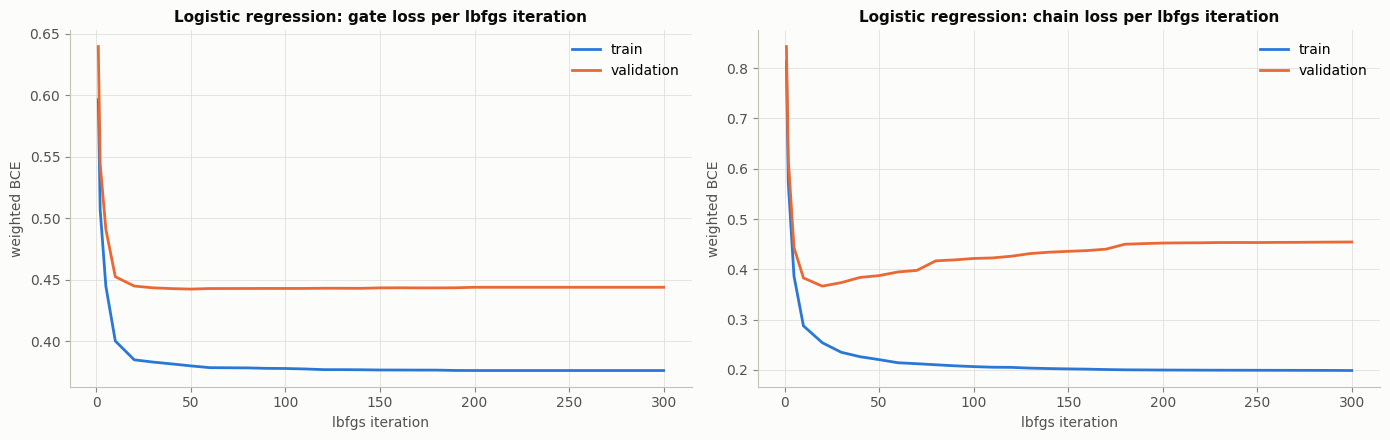

,train loss,validation loss,train accuracy,validation accuracy,validation label accuracy,macro precision,macro recall,macro F1
Logistic regression,0.334,0.604,0.607,0.571,0.948,0.705,0.819,0.752


In [16]:
LR_CURVE_STEPS = list(np.unique(np.r_[1, 2, 5, np.arange(10, 301, 10)]))
lr_curve_gate, lr_curve_chain = lr_curve_models(MODEL_FACTORIES["Logistic regression"](), LR_CURVE_STEPS, X)
model_results["Logistic regression"]["curves"] = chain_loss_curves(
    lr_curve_gate, lr_curve_chain, lr_staged_probas, LR_CURVE_STEPS, X)
show_loss_curves(model_results["Logistic regression"]["curves"], "Logistic regression", "lbfgs iteration")
show_model_summary(model_results, ["Logistic regression"]);


## KNN

`KNeighborsClassifier` with 15 distance-weighted neighbours. KNN has no class weights, so rare labels
(e.g. `spicy`) are only predicted when most close neighbours have them.

In [17]:
knn_gate, knn_chain = run_pipeline("KNN", "KNN", model_results)


KNN: fit 0.0s  train loss 0.003  validation loss 0.912  accuracy 0.688  micro F1 0.861  macro F1 0.821
                     precision    recall  f1-score   support

   advanced_gourmet       0.78      0.50      0.61        42
          breakfast       0.94      0.85      0.90       130
     crispy_crunchy       0.84      0.81      0.83       172
dessert_sweet_treat       0.79      0.84      0.82        74
               easy       0.88      0.93      0.91       853
            generic       0.82      0.84      0.83       533
     hearty_filling       0.82      0.87      0.85       471
       kid_friendly       0.90      0.84      0.87       398
    one_pot_one_pan       0.86      0.64      0.74       106
protein_centerpiece       0.90      0.98      0.94       452
       ready_to_eat       0.85      0.86      0.86       359
      smoky_grilled       0.98      0.96      0.97       187
              spicy       0.90      0.60      0.72        15
  street_food_style       0.83      0.78  

### KNN decision boundaries

`X` has 70 dimensions, so a boundary can't be drawn directly. The plot embeds `X` in 2-D with UMAP
(fit on train rows; a batch transform is fine for a picture) and refits a KNN with the **same settings** on those two coordinates. The shaded
regions are that 2-D surrogate's boundary, not the 70-D model's; the printed accuracies show how much is lost.
Left: the `generic` gate (all train rows). Right: the `kid_friendly` chain link (non-generic train rows).

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


generic: 2-D surrogate test accuracy 0.890
kid_friendly: 2-D surrogate test accuracy 0.930


real 70-D KNN gate test accuracy 0.914


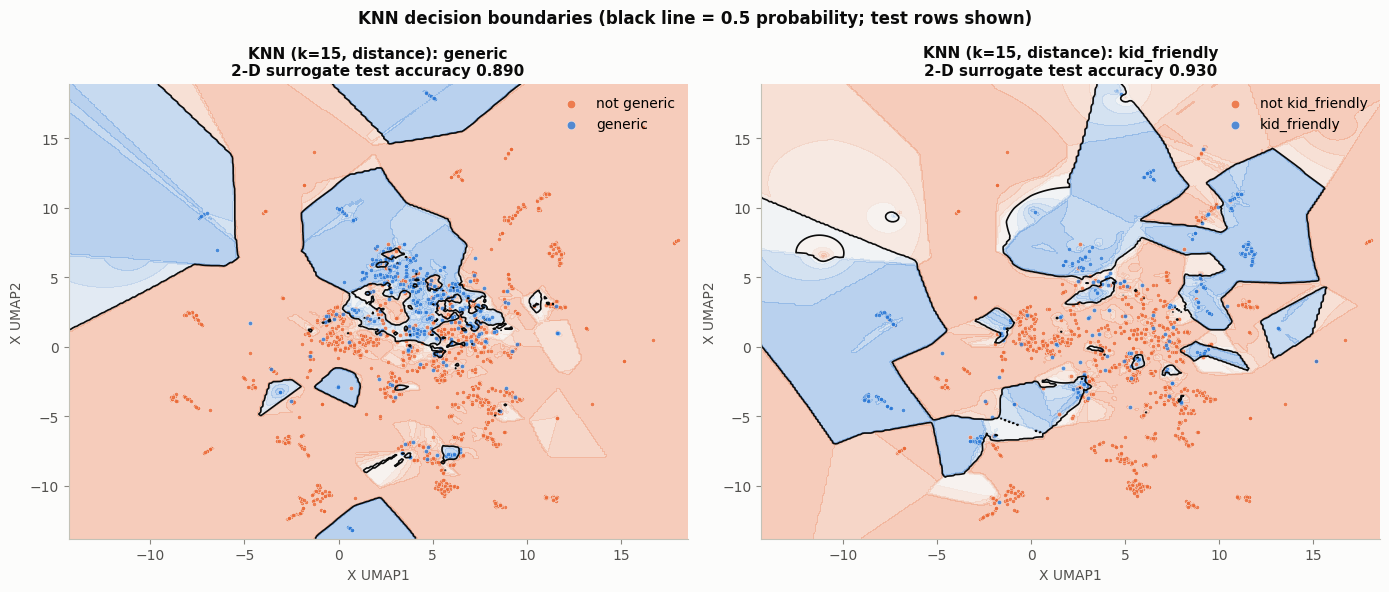

In [18]:
from matplotlib.colors import LinearSegmentedColormap

viz_proj = umap.UMAP(n_components=2, random_state=RANDOM_STATE).fit(X[train_idx])
viz_X2 = viz_proj.transform(X)
viz_region_cmap = LinearSegmentedColormap.from_list("region", [SERIES[1], "#f0efec", SERIES[0]])
viz_rng = np.random.default_rng(RANDOM_STATE)
viz_pad = 0.5
viz_xx, viz_yy = np.meshgrid(
    np.linspace(viz_X2[:, 0].min() - viz_pad, viz_X2[:, 0].max() + viz_pad, 300),
    np.linspace(viz_X2[:, 1].min() - viz_pad, viz_X2[:, 1].max() + viz_pad, 300))
viz_grid = np.c_[viz_xx.ravel(), viz_yy.ravel()]


def viz_targets(label):
    """(fit rows, test rows, y over all rows) for the gate or one chain link, as in the gated pipeline."""
    if label == "generic":
        return train_idx, test_idx, Y_np[:, GENERIC]
    test_rows = test_idx[Y_np[test_idx, GENERIC] == 0]
    return specific_train_idx, test_rows, Y_np[:, LABEL_COLS.index(label)]


def viz_scatter(ax, rows, y, label, n=2500):
    shown = viz_rng.choice(rows, size=min(n, len(rows)), replace=False)
    for cls, color, name in [(0, SERIES[1], f"not {label}"), (1, SERIES[0], label)]:
        pts = viz_X2[shown][y[shown] == cls]
        ax.scatter(pts[:, 0], pts[:, 1], s=9, color=color, edgecolors=SURFACE, linewidths=0.3, alpha=0.8, label=name)
    ax.set_xlabel("X UMAP1")
    ax.set_ylabel("X UMAP2")
    ax.grid(False)


fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, label in zip(axes, ["generic", "kid_friendly"]):
    fit_rows, test_rows, y = viz_targets(label)
    viz_knn = clone(knn_gate).fit(viz_X2[fit_rows], y[fit_rows])
    proba = viz_knn.predict_proba(viz_grid)[:, 1].reshape(viz_xx.shape)
    ax.contourf(viz_xx, viz_yy, proba, levels=np.linspace(0, 1, 11), cmap=viz_region_cmap, alpha=0.35)
    ax.contour(viz_xx, viz_yy, proba, levels=[0.5], colors=INK, linewidths=1.2)
    viz_scatter(ax, test_rows, y, label)
    acc_2d = accuracy_score(y[test_rows], viz_knn.predict(viz_X2[test_rows]))
    ax.set_title(f"KNN (k={knn_gate.n_neighbors}, {knn_gate.weights}): {label}\n"
                 f"2-D surrogate test accuracy {acc_2d:.3f}")
    ax.legend(loc="upper right", markerscale=2)
    print(f"{label}: 2-D surrogate test accuracy {acc_2d:.3f}")
print(f"real 70-D KNN gate test accuracy {accuracy_score(Y_np[test_idx, GENERIC], knn_gate.predict(X[test_idx])):.3f}")
fig.suptitle("KNN decision boundaries (black line = 0.5 probability; test rows shown)", color=INK, fontweight="bold")
fig.tight_layout()
plt.show()

### KNN: train vs validation

KNN has no training steps (it stores the rows), so no epochs. With distance weighting a train row is its own nearest
neighbour at distance 0, so its train loss and accuracy are near perfect by construction; only the validation numbers
say how well it generalises.


In [19]:
show_model_summary(model_results, ["KNN"]);


,train loss,validation loss,train accuracy,validation accuracy,validation label accuracy,macro precision,macro recall,macro F1
KNN,0.003,0.912,0.998,0.688,0.965,0.859,0.795,0.821


## Decision Tree

`DecisionTreeClassifier` with balanced class weights and at least 5 rows per leaf, as the generic gate and every chain link.

In [20]:
dt_gate, dt_chain = run_pipeline("Decision Tree", "Decision Tree", model_results)


Decision Tree: fit 7.2s  train loss 0.214  validation loss 2.577  accuracy 0.569  micro F1 0.800  macro F1 0.744
                     precision    recall  f1-score   support

   advanced_gourmet       0.44      0.60      0.51        42
          breakfast       0.76      0.82      0.79       130
     crispy_crunchy       0.71      0.78      0.75       172
dessert_sweet_treat       0.68      0.77      0.72        74
               easy       0.88      0.85      0.86       853
            generic       0.69      0.83      0.76       533
     hearty_filling       0.84      0.87      0.86       471
       kid_friendly       0.78      0.81      0.80       398
    one_pot_one_pan       0.63      0.65      0.64       106
protein_centerpiece       0.91      0.95      0.93       452
       ready_to_eat       0.78      0.81      0.80       359
      smoky_grilled       0.89      0.95      0.92       187
              spicy       0.57      0.53      0.55        15
  street_food_style       0.62  

### Decision tree structure

The top 3 levels of two trees: the `generic` gate (`dt_gate`, sees only `X`) and the `spicy` link of the chain
(`dt_chain`, late in the chain, so it can also split on the labels predicted before it, shown as `label:<name>`).
`emb_*` are attention-embedding dimensions and `nutrient_UMAP*` are nutrient UMAP components.
Each node shows the split, its weighted gini impurity, sample count and the class weights (`value`).

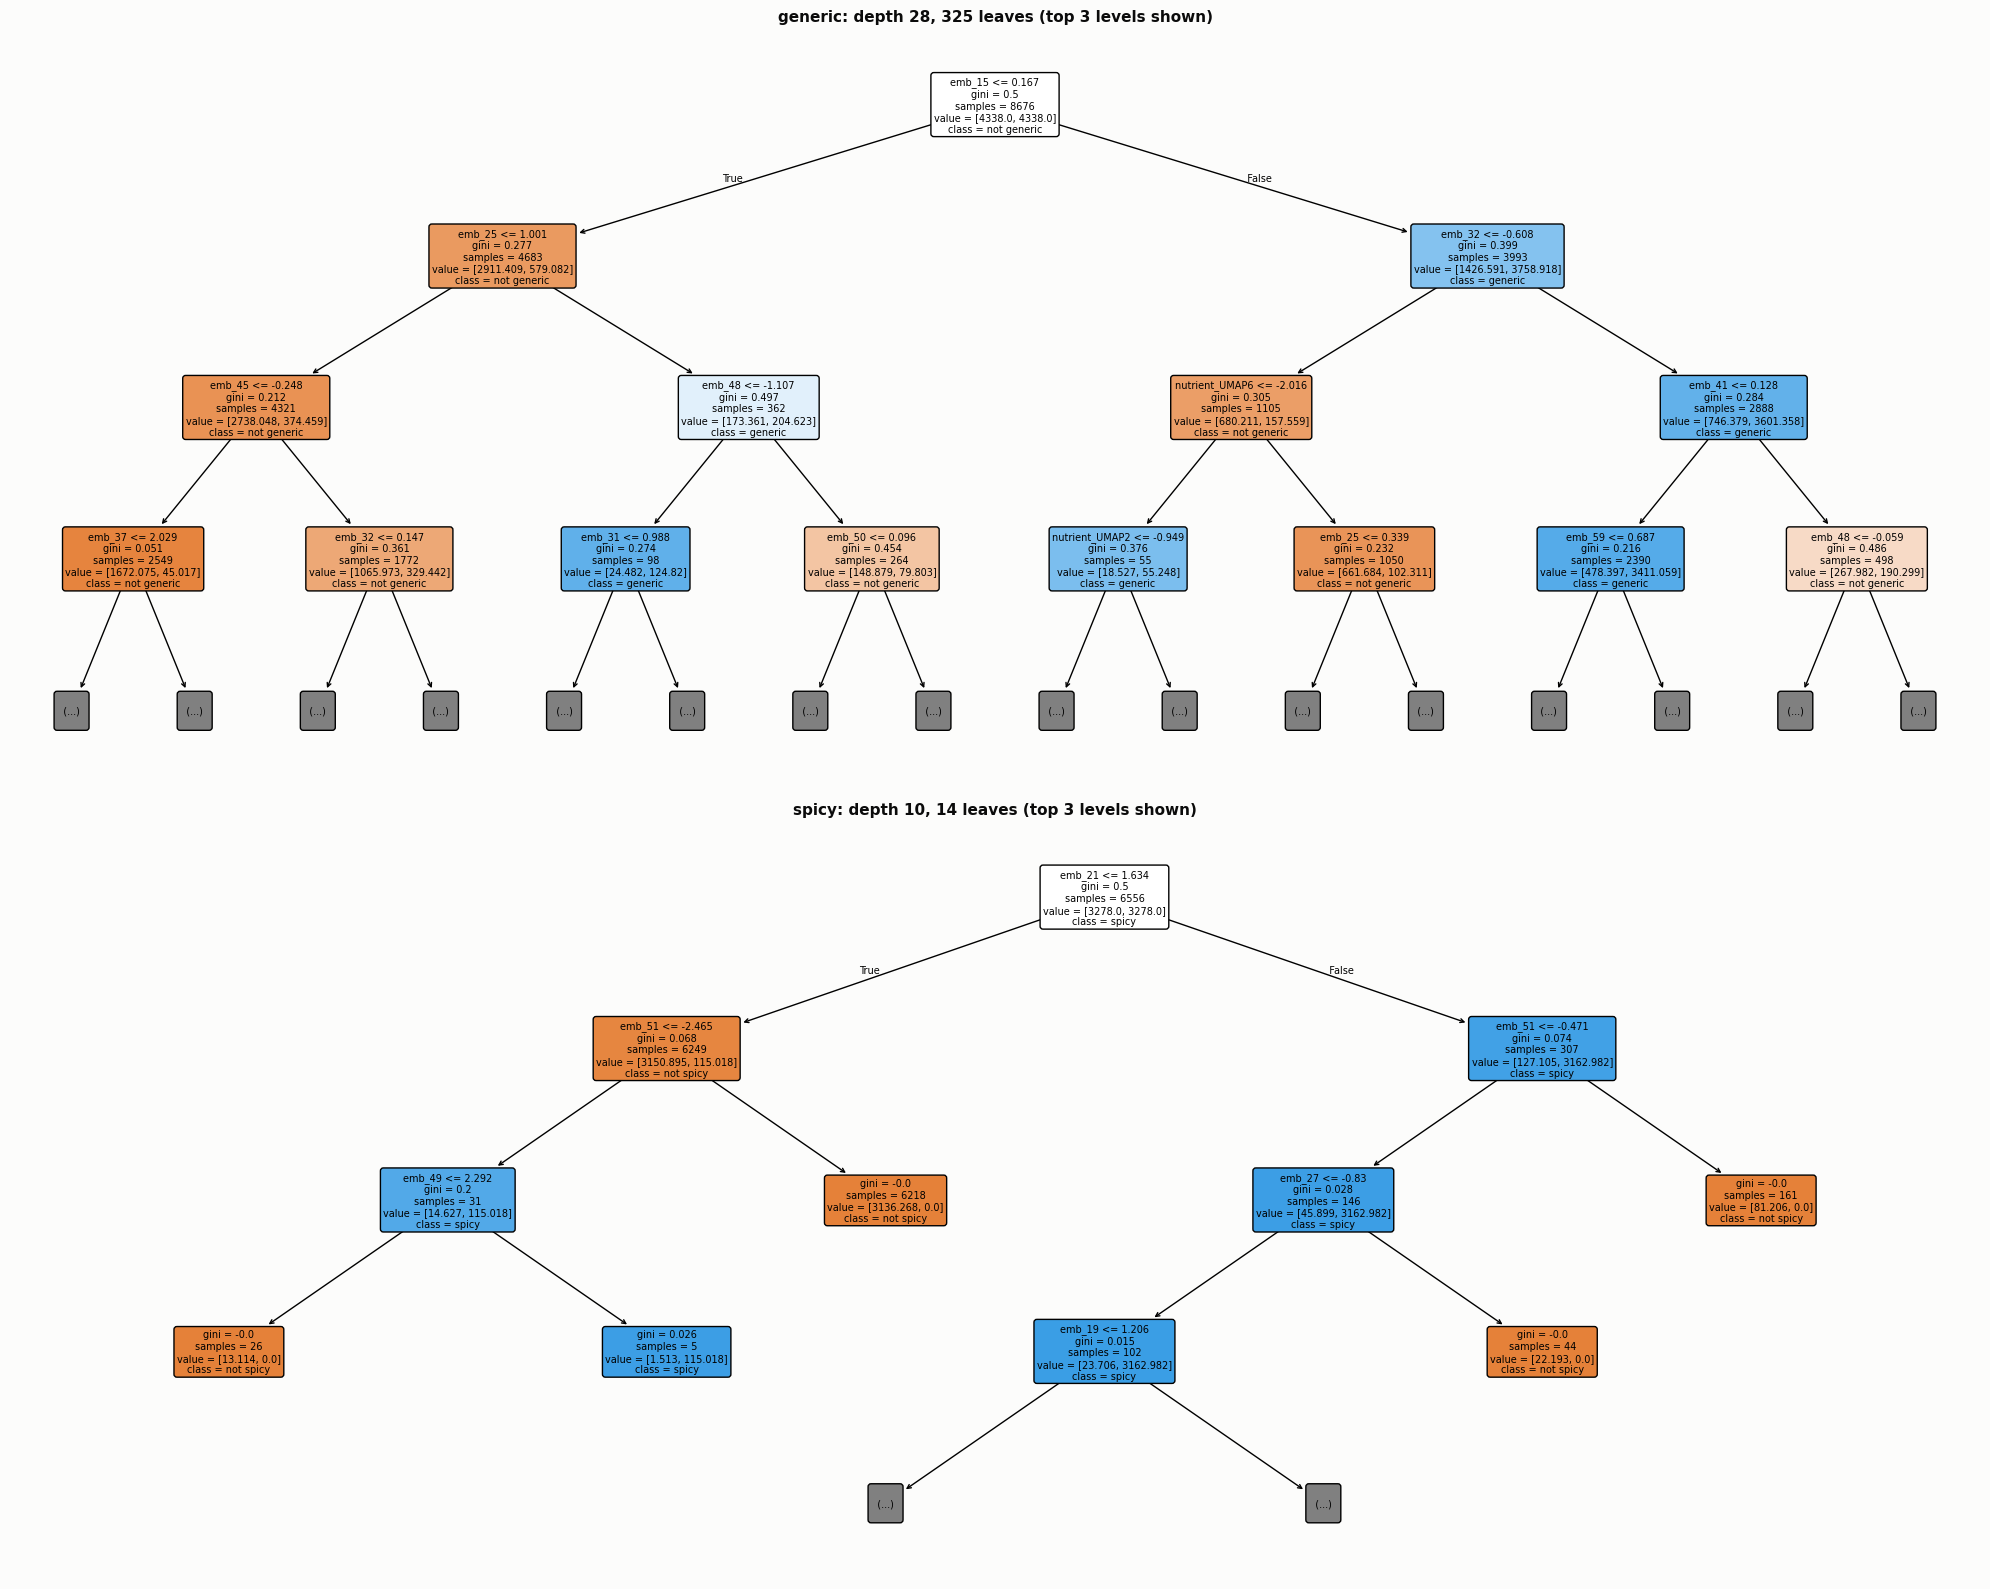

In [21]:
from sklearn.tree import plot_tree

viz_feature_names = [f"emb_{i}" for i in range(EMB_DIM)] + [f"nutrient_UMAP{i + 1}" for i in range(nutrient_umap_comps.shape[1])]


def viz_chain_feature_names(order, labels, position):
    """Features seen by chain link `position`: X, then the labels predicted before it in chain order."""
    return viz_feature_names + [f"label:{labels[j]}" for j in order[:position]]


def viz_plot_tree(ax, tree, feature_names, label, depth=3):
    plot_tree(tree, max_depth=depth, feature_names=feature_names, class_names=[f"not {label}", label],
              filled=True, rounded=True, impurity=True, proportion=False, fontsize=7, ax=ax)
    ax.set_title(f"{label}: depth {tree.get_depth()}, {tree.get_n_leaves()} leaves (top {depth} levels shown)")


fig, axes = plt.subplots(2, 1, figsize=(20, 16))
viz_plot_tree(axes[0], dt_gate, viz_feature_names, "generic")
viz_position = list(chain_order).index(CHAIN_LABELS.index("spicy"))
viz_plot_tree(axes[1], dt_chain.estimators_[viz_position],
              viz_chain_feature_names(chain_order, CHAIN_LABELS, viz_position), "spicy")
fig.tight_layout()
plt.show()

### Decision Tree: train vs validation

A tree is grown in one pass, so no epochs. The gap between train and validation loss shows how much it overfits
(leaves of 5 rows give very confident probabilities).


In [22]:
show_model_summary(model_results, ["Decision Tree"]);


,train loss,validation loss,train accuracy,validation accuracy,validation label accuracy,macro precision,macro recall,macro F1
Decision Tree,0.214,2.577,0.783,0.569,0.948,0.713,0.781,0.744


## SVM

RBF-kernel `SVC` with balanced class weights. `probability=True` is needed for the chain's fallback
(a non-generic row with no label gets its most likely one) and makes fitting slower (internal 5-fold Platt scaling).

In [23]:
svm_gate, svm_chain = run_pipeline("SVM", "SVM", model_results)


SVM: fit 61.2s  train loss 0.269  validation loss 0.587  accuracy 0.645  micro F1 0.847  macro F1 0.803
                     precision    recall  f1-score   support

   advanced_gourmet       0.45      0.71      0.55        42
          breakfast       0.92      0.92      0.92       130
     crispy_crunchy       0.69      0.88      0.78       172
dessert_sweet_treat       0.63      0.91      0.74        74
               easy       0.90      0.90      0.90       853
            generic       0.74      0.92      0.82       533
     hearty_filling       0.84      0.90      0.87       471
       kid_friendly       0.86      0.85      0.86       398
    one_pot_one_pan       0.57      0.80      0.67       106
protein_centerpiece       0.90      0.98      0.94       452
       ready_to_eat       0.85      0.86      0.86       359
      smoky_grilled       0.97      0.98      0.97       187
              spicy       0.71      0.67      0.69        15
  street_food_style       0.76      0.88 

### SVM margin

Same 2-D projection as the KNN plot, so again a surrogate: an SVM with the model's settings is refit on the two
coordinates of a 3,000-row train sample (only the `generic` gate). The solid line is the decision boundary
(decision function = 0), the dashed lines are the margins (±1), and ringed points are support vectors.
Left: the model's RBF kernel. Right: a linear kernel for comparison, where the margin is a straight band.

real 70-D SVM gate test accuracy 0.900


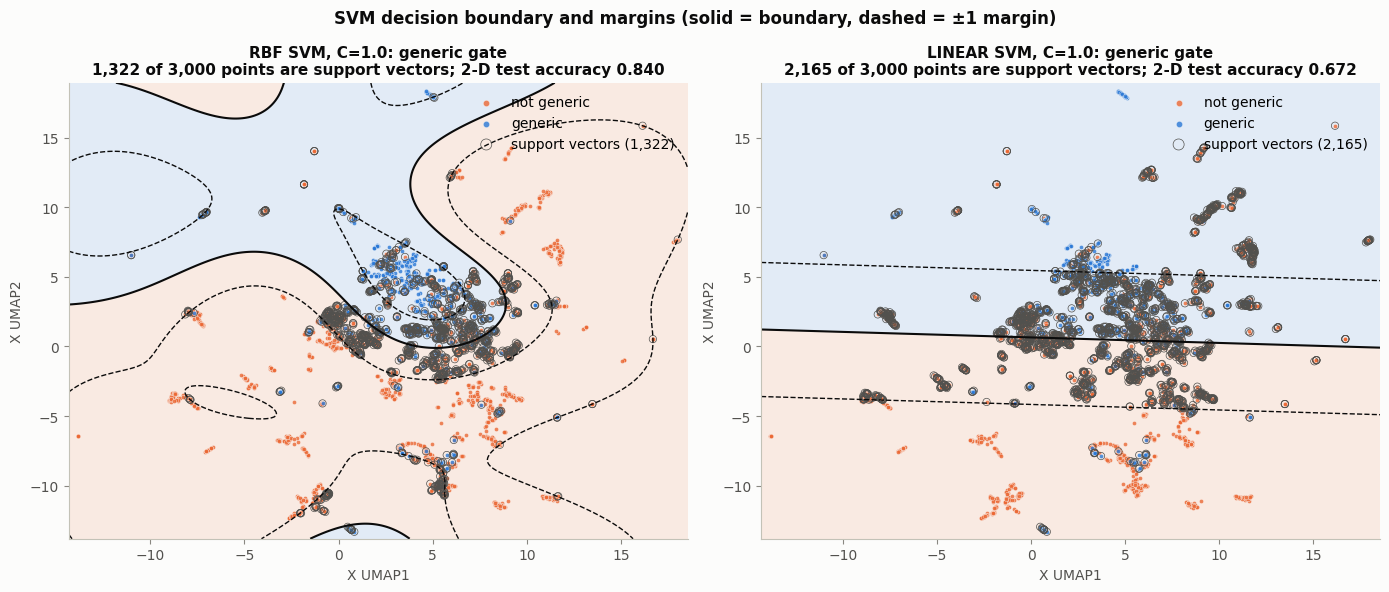

In [24]:
viz_fit_rows = viz_rng.choice(train_idx, size=3000, replace=False)
viz_y = Y_np[:, GENERIC]
viz_svm_params = {k: v for k, v in svm_gate.get_params().items() if k != "probability"}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, kernel in zip(axes, ["rbf", "linear"]):
    viz_svm = SVC(**{**viz_svm_params, "kernel": kernel}).fit(viz_X2[viz_fit_rows], viz_y[viz_fit_rows])
    decision = viz_svm.decision_function(viz_grid).reshape(viz_xx.shape)
    ax.contourf(viz_xx, viz_yy, decision, levels=[-np.inf, 0, np.inf], colors=[SERIES[1], SERIES[0]], alpha=0.12)
    ax.contour(viz_xx, viz_yy, decision, levels=[-1, 0, 1], colors=INK, linestyles=["--", "-", "--"],
               linewidths=[1, 1.5, 1])
    viz_scatter(ax, viz_fit_rows, viz_y, "generic", n=len(viz_fit_rows))
    sv = viz_X2[viz_fit_rows][viz_svm.support_]
    ax.scatter(sv[:, 0], sv[:, 1], s=28, facecolors="none", edgecolors=INK_2, linewidths=0.5,
               label=f"support vectors ({len(sv):,})")
    test_acc = accuracy_score(viz_y[test_idx], viz_svm.predict(viz_X2[test_idx]))
    ax.set_title(f"{kernel.upper()} SVM, C={viz_svm.C}: generic gate\n"
                 f"{len(sv):,} of {len(viz_fit_rows):,} points are support vectors; 2-D test accuracy {test_acc:.3f}")
    ax.legend(loc="upper right", markerscale=1.5)
print(f"real 70-D SVM gate test accuracy {accuracy_score(Y_np[test_idx, GENERIC], svm_gate.predict(X[test_idx])):.3f}")
fig.suptitle("SVM decision boundary and margins (solid = boundary, dashed = ±1 margin)", color=INK, fontweight="bold")
fig.tight_layout()
plt.show()

### SVM: train vs validation

The SVM is solved in one optimisation (no epochs); its probabilities come from Platt scaling.


In [25]:
show_model_summary(model_results, ["SVM"]);


,train loss,validation loss,train accuracy,validation accuracy,validation label accuracy,macro precision,macro recall,macro F1
SVM,0.269,0.587,0.693,0.645,0.959,0.758,0.864,0.803


## XGBoost

`BalancedXGB` (defined in the setup) is fitted per label, so it sets `scale_pos_weight` (negatives / positives) from
each label it is fitted on. It uses the L2 strength `reg_lambda` chosen in the L2 section and **early stopping**: 15% of
its rows (stratified) are held out, boosting stops once their weighted log loss has not improved for 30 rounds (at most
300), and the model is refit on all its rows with that many rounds. The curves below go flat after that round.

XGBoost segfaults in this process: torch is already loaded, and its OpenMP runtime clashes with XGBoost's
(same issue as LightGBM, and `n_jobs=1` does not avoid it). So the gate and chain are fitted and used for prediction
in a separate loky worker process that never imports torch; only the test predictions come back.

In [26]:
XGB_CURVE_STEPS = [1, 5] + list(range(10, 301, 10))  # boosting rounds (n_estimators=300)


def xgb_staged_probas(model, X_rows, steps):
    """Probability of a fitted BalancedXGB using only its first k boosting rounds, for each k in `steps`."""
    return [model.model_.predict_proba(X_rows, iteration_range=(0, min(k, model.best_n_estimators_)))[:, 1]
            for k in steps]  # flat after the round early stopping picked


run_pipeline("XGBoost", "XGBoost", model_results, curves=(xgb_staged_probas, XGB_CURVE_STEPS));


XGBoost: fit 8.9s  train loss 0.066  validation loss 0.619  accuracy 0.728  micro F1 0.878  macro F1 0.831
                     precision    recall  f1-score   support

   advanced_gourmet       0.69      0.60      0.64        42
          breakfast       0.97      0.89      0.93       130
     crispy_crunchy       0.81      0.83      0.82       172
dessert_sweet_treat       0.82      0.86      0.84        74
               easy       0.91      0.93      0.92       853
            generic       0.77      0.90      0.83       533
     hearty_filling       0.93      0.91      0.92       471
       kid_friendly       0.86      0.86      0.86       398
    one_pot_one_pan       0.83      0.76      0.79       106
protein_centerpiece       0.94      0.98      0.96       452
       ready_to_eat       0.87      0.88      0.88       359
      smoky_grilled       0.98      0.97      0.98       187
              spicy       0.67      0.40      0.50        15
  street_food_style       0.85      0.

### XGBoost: loss per boosting round and summary

Weighted BCE after every 10 boosting rounds (computed in the worker from the fitted models, using only the first k
trees). A validation curve that flattens or rises while the train curve keeps falling means more rounds only overfit.


,gate train,gate validation,chain train,chain validation
boosting round,,,,
1,0.9612,0.9661,1.1857,1.1977
5,0.7223,0.7485,0.7954,0.8475
10,0.5621,0.6037,0.5341,0.6256
20,0.4093,0.4744,0.2947,0.4486
30,0.3403,0.4262,0.1969,0.3994
40,0.3041,0.4059,0.1502,0.3886
50,0.2816,0.3944,0.1241,0.3936
60,0.2647,0.3866,0.1069,0.4007
70,0.2496,0.3827,0.0944,0.4167


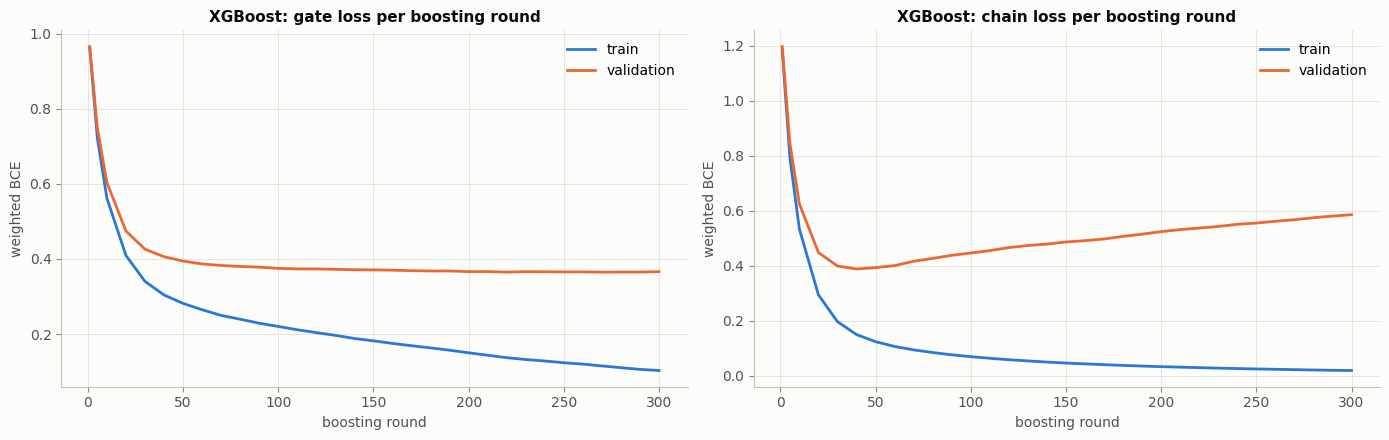

,train loss,validation loss,train accuracy,validation accuracy,validation label accuracy,macro precision,macro recall,macro F1
XGBoost,0.066,0.619,0.961,0.728,0.969,0.841,0.828,0.831


In [27]:
show_loss_curves(model_results["XGBoost"]["curves"], "XGBoost", "boosting round")
show_model_summary(model_results, ["XGBoost"]);


## Random Forest

300 trees with `class_weight="balanced_subsample"` (class weights recomputed on each bootstrap sample).

In [28]:
rf_gate, rf_chain = run_pipeline("Random Forest", "Random Forest", model_results)


Random Forest: fit 25.1s  train loss 0.131  validation loss 0.618  accuracy 0.710  micro F1 0.873  macro F1 0.827
                     precision    recall  f1-score   support

   advanced_gourmet       0.72      0.55      0.62        42
          breakfast       0.98      0.88      0.93       130
     crispy_crunchy       0.86      0.83      0.84       172
dessert_sweet_treat       0.84      0.76      0.79        74
               easy       0.89      0.94      0.91       853
            generic       0.82      0.84      0.83       533
     hearty_filling       0.91      0.90      0.91       471
       kid_friendly       0.87      0.84      0.86       398
    one_pot_one_pan       0.87      0.64      0.74       106
protein_centerpiece       0.92      0.98      0.95       452
       ready_to_eat       0.85      0.87      0.86       359
      smoky_grilled       0.98      0.94      0.96       187
              spicy       0.78      0.47      0.58        15
  street_food_style       0.94 

### Random Forest trees

One of the 300 trees of the `generic` gate (top 3 levels), and the gate's impurity-based feature importances
averaged over all its trees (top 15).

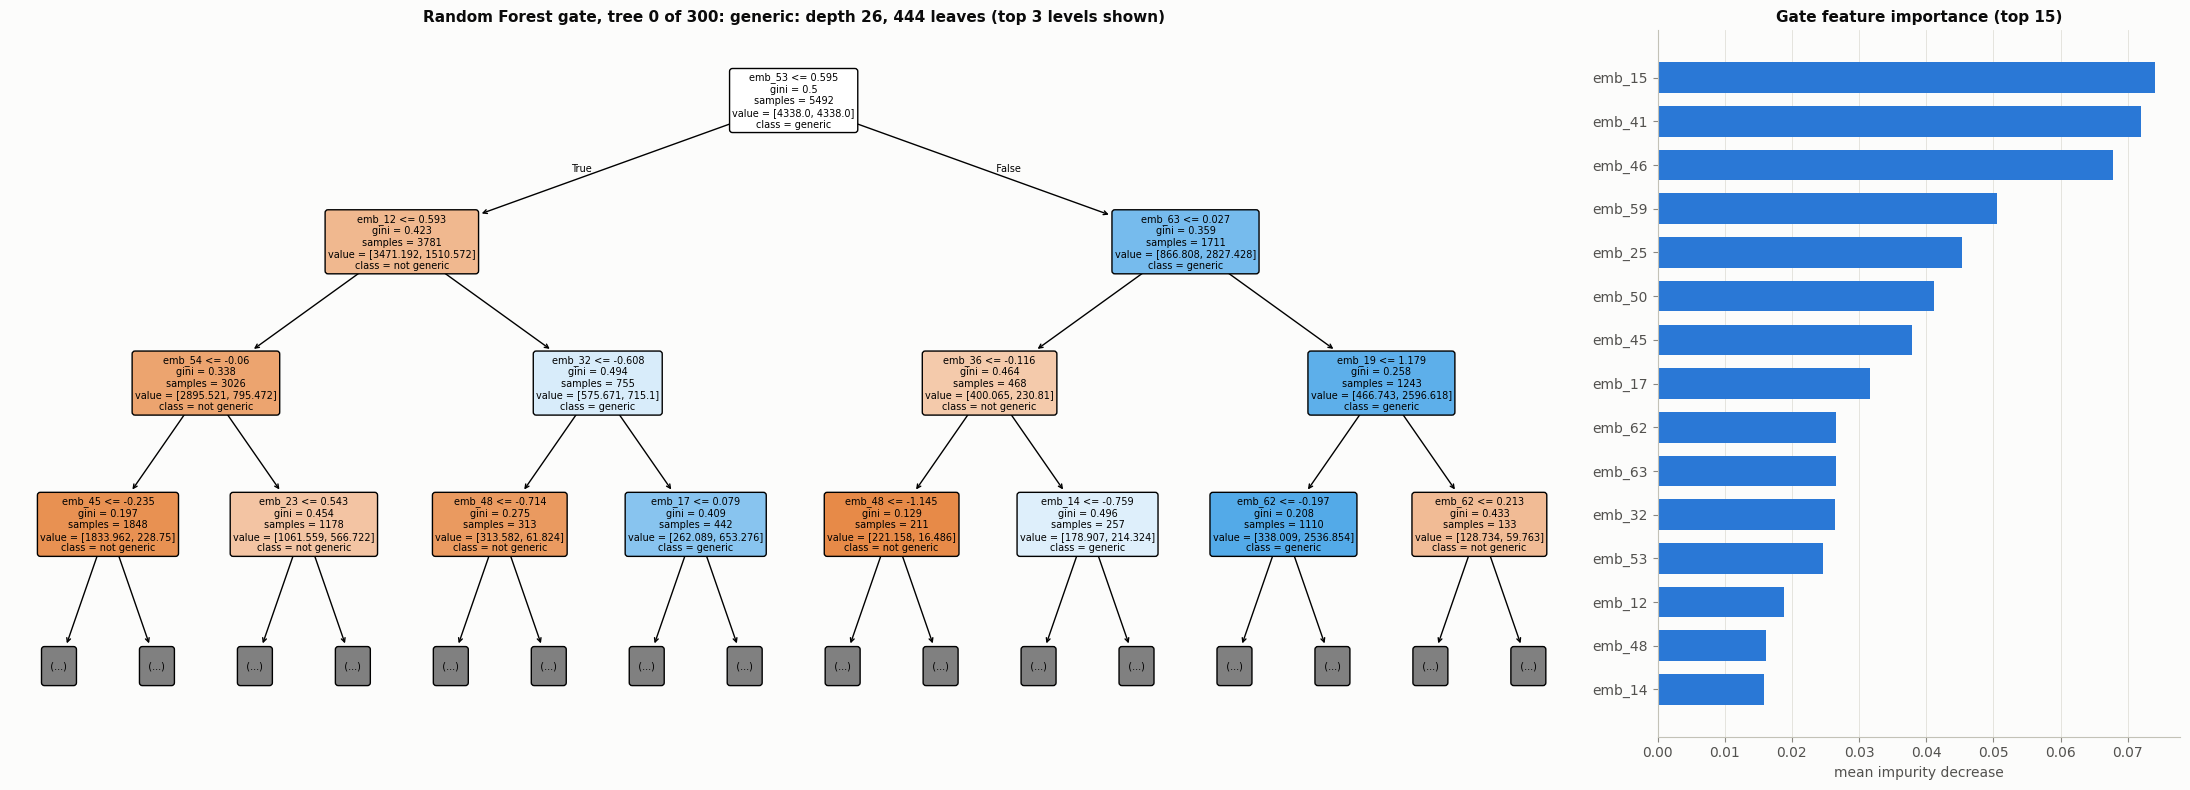

In [29]:
viz_rf_importance = pd.Series(rf_gate.feature_importances_, index=viz_feature_names).sort_values()

fig, (ax_tree, ax_imp) = plt.subplots(1, 2, figsize=(22, 8), gridspec_kw={"width_ratios": [3, 1]})
viz_plot_tree(ax_tree, rf_gate.estimators_[0], viz_feature_names, "generic")
ax_tree.set_title("Random Forest gate, tree 0 of " + f"{len(rf_gate.estimators_)}: " + ax_tree.get_title())
viz_top = viz_rf_importance.tail(15)
ax_imp.barh(viz_top.index, viz_top.values, color=SERIES[0], height=0.7)
ax_imp.grid(axis="y", visible=False)
ax_imp.set_xlabel("mean impurity decrease")
ax_imp.set_title("Gate feature importance (top 15)")
fig.tight_layout()
plt.show()

### Random Forest: loss per tree and summary

Trees are independent, so the "epochs" here are the number of trees averaged so far (the forest's probability with its
first k trees).


,gate train,gate validation,chain train,chain validation
tree,,,,
1,1.3001,3.3038,1.4877,4.4993
5,0.1543,0.8419,0.1399,1.4571
10,0.1446,0.5454,0.1287,1.1034
20,0.1409,0.4997,0.1261,0.8535
30,0.1386,0.4776,0.1258,0.8015
40,0.1379,0.4244,0.1249,0.7492
50,0.1381,0.4232,0.1249,0.7157
60,0.1384,0.4016,0.1248,0.7013
70,0.1380,0.3832,0.1245,0.7027


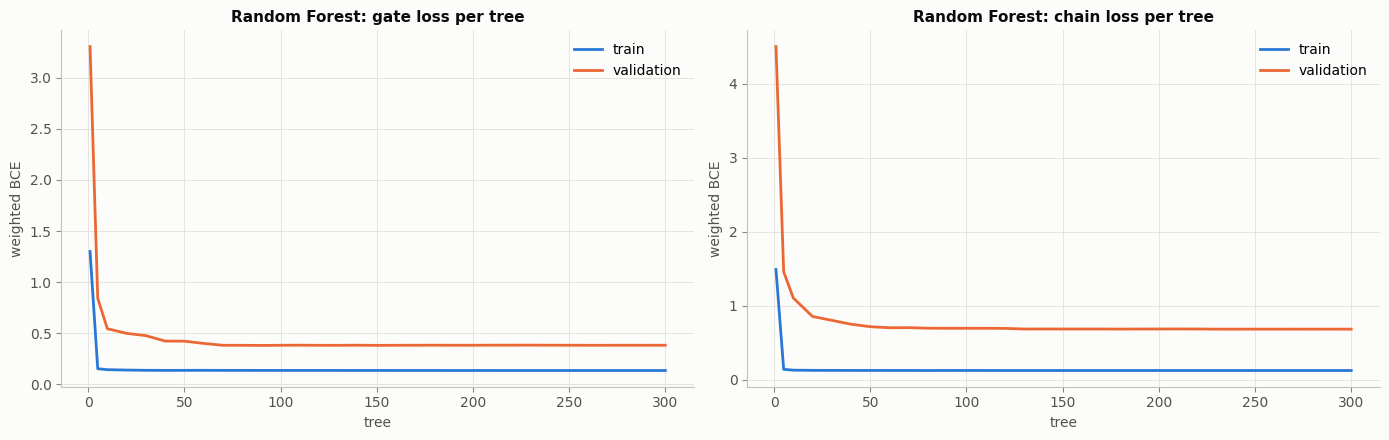

,train loss,validation loss,train accuracy,validation accuracy,validation label accuracy,macro precision,macro recall,macro F1
Random Forest,0.131,0.618,0.959,0.710,0.968,0.869,0.797,0.827


In [30]:
RF_CURVE_STEPS = [1, 5] + list(range(10, 301, 10))
model_results["Random Forest"]["curves"] = chain_loss_curves(rf_gate, rf_chain, rf_staged_probas, RF_CURVE_STEPS, X)
show_loss_curves(model_results["Random Forest"]["curves"], "Random Forest", "tree")
show_model_summary(model_results, ["Random Forest"]);


## Comparison

All scores are on the same test split (sorted by macro F1). Macro F1 weights every label equally, so it is the
fairest single number for the rare labels; micro F1 is dominated by the large labels (`easy`, `hearty_filling`, `protein_centerpiece`, `kid_friendly`).
`no label` / `generic + other` count test rows that break the label rules (should stay 0 with a gate).
Same caveat as above: labels are rule-based silver labels, so this ranks how well each model recovers the rules.

In [31]:
def show_comparison(results):
    """Overall scores table and per-label F1 table for {name: {"pred", "fit_seconds"}}; returns the scores table."""
    table = pd.DataFrame({
        name: {
            "micro F1": f1_score(Y_true, r["pred"], average="micro"),
            "macro F1": f1_score(Y_true, r["pred"], average="macro"),
            "samples F1": f1_score(Y_true, r["pred"], average="samples", zero_division=0),
            "generic F1": f1_score(Y_true[:, GENERIC], r["pred"][:, GENERIC]),
            "macro precision": precision_score(Y_true, r["pred"], average="macro", zero_division=0),
            "macro recall": recall_score(Y_true, r["pred"], average="macro", zero_division=0),
            "validation loss": weighted_bce(Y_true, r["proba"], LABEL_POS_WEIGHT).mean(),
            "hamming loss": hamming_loss(Y_true, r["pred"]),
            "exact match": accuracy_score(Y_true, r["pred"]),
            "no label": int((r["pred"].sum(1) == 0).sum()),
            "generic + other": int(((r["pred"][:, GENERIC] == 1) & (r["pred"].sum(1) > 1)).sum()),
            "fit seconds": r["fit_seconds"],
        }
        for name, r in results.items()
    }).T.sort_values("macro F1", ascending=False)

    score_cols = ["micro F1", "macro F1", "samples F1", "generic F1", "macro precision", "macro recall", "exact match"]
    loss_cols = ["validation loss", "hamming loss"]
    display(table.style
            .format({c: "{:.3f}" for c in score_cols + loss_cols} | {"no label": "{:.0f}", "generic + other": "{:.0f}",
                                                                   "fit seconds": "{:.1f}"})
            .background_gradient(cmap="Greens", subset=score_cols)
            .background_gradient(cmap="Greens_r", subset=loss_cols))

    per_label = pd.DataFrame(
        {name: f1_score(Y_true, r["pred"], average=None, zero_division=0) for name, r in results.items()},
        index=LABEL_COLS,
    )[table.index]
    per_label["support"] = Y_true.sum(0)
    per_label = per_label.sort_values("support", ascending=False)
    display(per_label.style
            .format("{:.2f}", subset=list(table.index))
            .background_gradient(cmap="Greens", axis=1, subset=list(table.index)))
    return table


comparison = show_comparison(model_results)

,micro F1,macro F1,samples F1,generic F1,macro precision,macro recall,validation loss,hamming loss,exact match,no label,generic + other,fit seconds
XGBoost,0.878,0.831,0.850,0.833,0.841,0.828,0.619,0.031,0.728,0,0,8.9
Random Forest,0.873,0.827,0.841,0.830,0.869,0.797,0.618,0.032,0.710,0,0,25.1
KNN,0.861,0.821,0.835,0.827,0.859,0.795,0.912,0.035,0.688,0,0,0.0
SVM,0.847,0.803,0.822,0.820,0.758,0.864,0.587,0.041,0.645,0,0,61.2
Logistic regression,0.808,0.752,0.777,0.774,0.705,0.819,0.604,0.052,0.571,0,0,0.5
Decision Tree,0.800,0.744,0.765,0.756,0.713,0.781,2.577,0.052,0.569,0,0,7.2


,XGBoost,Random Forest,KNN,SVM,Logistic regression,Decision Tree,support
easy,0.92,0.91,0.91,0.90,0.88,0.86,853
generic,0.83,0.83,0.83,0.82,0.77,0.76,533
hearty_filling,0.92,0.91,0.85,0.87,0.84,0.86,471
protein_centerpiece,0.96,0.95,0.94,0.94,0.93,0.93,452
kid_friendly,0.86,0.86,0.87,0.86,0.81,0.80,398
ready_to_eat,0.88,0.86,0.86,0.86,0.82,0.80,359
umami_rich,0.78,0.78,0.78,0.74,0.67,0.66,354
smoky_grilled,0.98,0.96,0.97,0.97,0.97,0.92,187
crispy_crunchy,0.82,0.84,0.83,0.78,0.73,0.75,172
breakfast,0.93,0.93,0.90,0.92,0.82,0.79,130


## Logistic-regression gate + chain of each model

One shared generic gate for every model: the logistic-regression `generic_gate` from the main model decides
generic vs not. Generic rows stop there (`{generic}`); the rest go through a classifier chain of XGBoost,
Random Forest, KNN, SVM, Decision Tree or logistic regression over the 15 specific labels (same settings as the
sections above). `fit seconds` covers the chain only, since the gate is shared. The logistic-regression row is the
main model again, so it matches it exactly.

In [32]:
lr_gate_results = {}  # chain model name -> results, all behind the shared LR gate

for name in MODEL_FACTORIES:
    run_pipeline(name, name, lr_gate_results, gate="lr")
assert (lr_gate_results["Logistic regression"]["pred"] == Y_pred).all()
show_model_summary(lr_gate_results);


Logistic regression: fit 0.4s  train loss 0.334  validation loss 0.604  accuracy 0.571  micro F1 0.808  macro F1 0.752
                     precision    recall  f1-score   support

   advanced_gourmet       0.36      0.52      0.43        42
          breakfast       0.76      0.89      0.82       130
     crispy_crunchy       0.66      0.83      0.73       172
dessert_sweet_treat       0.64      0.84      0.73        74
               easy       0.88      0.87      0.88       853
            generic       0.69      0.89      0.77       533
     hearty_filling       0.80      0.89      0.84       471
       kid_friendly       0.79      0.83      0.81       398
    one_pot_one_pan       0.51      0.78      0.62       106
protein_centerpiece       0.90      0.98      0.93       452
       ready_to_eat       0.81      0.83      0.82       359
      smoky_grilled       0.95      0.99      0.97       187
              spicy       0.73      0.53      0.62        15
  street_food_style       

KNN: fit 0.0s  train loss 0.171  validation loss 0.964  accuracy 0.662  micro F1 0.840  macro F1 0.805
                     precision    recall  f1-score   support

   advanced_gourmet       0.76      0.45      0.57        42
          breakfast       0.96      0.84      0.89       130
     crispy_crunchy       0.83      0.76      0.79       172
dessert_sweet_treat       0.78      0.77      0.78        74
               easy       0.88      0.90      0.89       853
            generic       0.69      0.89      0.77       533
     hearty_filling       0.85      0.85      0.85       471
       kid_friendly       0.90      0.79      0.84       398
    one_pot_one_pan       0.88      0.62      0.73       106
protein_centerpiece       0.90      0.97      0.94       452
       ready_to_eat       0.85      0.82      0.83       359
      smoky_grilled       0.98      0.96      0.97       187
              spicy       1.00      0.60      0.75        15
  street_food_style       0.84      0.77  

Decision Tree: fit 5.2s  train loss 0.316  validation loss 2.244  accuracy 0.579  micro F1 0.809  macro F1 0.750
                     precision    recall  f1-score   support

   advanced_gourmet       0.49      0.52      0.51        42
          breakfast       0.79      0.86      0.82       130
     crispy_crunchy       0.70      0.79      0.75       172
dessert_sweet_treat       0.68      0.76      0.72        74
               easy       0.89      0.86      0.88       853
            generic       0.69      0.89      0.77       533
     hearty_filling       0.87      0.88      0.88       471
       kid_friendly       0.80      0.79      0.80       398
    one_pot_one_pan       0.69      0.66      0.67       106
protein_centerpiece       0.91      0.95      0.93       452
       ready_to_eat       0.79      0.79      0.79       359
      smoky_grilled       0.90      0.96      0.93       187
              spicy       0.53      0.53      0.53        15
  street_food_style       0.64  

SVM: fit 20.5s  train loss 0.357  validation loss 0.678  accuracy 0.622  micro F1 0.831  macro F1 0.785
                     precision    recall  f1-score   support

   advanced_gourmet       0.41      0.62      0.49        42
          breakfast       0.89      0.89      0.89       130
     crispy_crunchy       0.66      0.85      0.74       172
dessert_sweet_treat       0.62      0.85      0.72        74
               easy       0.89      0.89      0.89       853
            generic       0.69      0.89      0.77       533
     hearty_filling       0.83      0.90      0.86       471
       kid_friendly       0.85      0.83      0.84       398
    one_pot_one_pan       0.58      0.79      0.67       106
protein_centerpiece       0.90      0.98      0.94       452
       ready_to_eat       0.84      0.84      0.84       359
      smoky_grilled       0.97      0.98      0.97       187
              spicy       0.75      0.60      0.67        15
  street_food_style       0.75      0.86 

XGBoost: fit 11.1s  train loss 0.188  validation loss 0.685  accuracy 0.701  micro F1 0.858  macro F1 0.821
                     precision    recall  f1-score   support

   advanced_gourmet       0.71      0.57      0.63        42
          breakfast       0.97      0.88      0.92       130
     crispy_crunchy       0.79      0.80      0.80       172
dessert_sweet_treat       0.82      0.81      0.82        74
               easy       0.90      0.90      0.90       853
            generic       0.69      0.89      0.77       533
     hearty_filling       0.93      0.90      0.91       471
       kid_friendly       0.86      0.83      0.84       398
    one_pot_one_pan       0.84      0.73      0.78       106
protein_centerpiece       0.94      0.97      0.96       452
       ready_to_eat       0.87      0.84      0.85       359
      smoky_grilled       0.98      0.97      0.98       187
              spicy       0.78      0.47      0.58        15
  street_food_style       0.83      0

Random Forest: fit 21.6s  train loss 0.255  validation loss 0.709  accuracy 0.687  micro F1 0.852  macro F1 0.807
                     precision    recall  f1-score   support

   advanced_gourmet       0.71      0.52      0.60        42
          breakfast       0.97      0.86      0.91       130
     crispy_crunchy       0.85      0.77      0.81       172
dessert_sweet_treat       0.83      0.70      0.76        74
               easy       0.89      0.90      0.90       853
            generic       0.69      0.89      0.77       533
     hearty_filling       0.92      0.88      0.90       471
       kid_friendly       0.88      0.80      0.84       398
    one_pot_one_pan       0.89      0.60      0.72       106
protein_centerpiece       0.93      0.97      0.95       452
       ready_to_eat       0.87      0.82      0.84       359
      smoky_grilled       0.98      0.94      0.96       187
              spicy       0.86      0.40      0.55        15
  street_food_style       0.93 

,train loss,validation loss,train accuracy,validation accuracy,validation label accuracy,macro precision,macro recall,macro F1
Logistic regression,0.334,0.604,0.607,0.571,0.948,0.705,0.819,0.752
KNN,0.171,0.964,0.893,0.662,0.960,0.862,0.769,0.805
Decision Tree,0.316,2.244,0.735,0.579,0.950,0.726,0.780,0.750
SVM,0.357,0.678,0.667,0.622,0.955,0.747,0.837,0.785
XGBoost,0.188,0.685,0.878,0.701,0.964,0.842,0.807,0.821
Random Forest,0.255,0.709,0.866,0.687,0.963,0.869,0.767,0.807


## Comparison: own-model gate vs logistic-regression gate

Every model twice: `own gate` (the model is also the generic gate, sections above) and `LR gate` (shared
logistic-regression gate, previous section). With the same chain model, any difference comes from the gate alone;
`generic F1` shows how good each gate is.

In [33]:
gate_comparison = show_comparison(
    {f"{name} | own gate": r for name, r in model_results.items()}
    | {f"{name} | LR gate": r for name, r in lr_gate_results.items()})

,micro F1,macro F1,samples F1,generic F1,macro precision,macro recall,validation loss,hamming loss,exact match,no label,generic + other,fit seconds
XGBoost | own gate,0.878,0.831,0.850,0.833,0.841,0.828,0.619,0.031,0.728,0,0,8.9
Random Forest | own gate,0.873,0.827,0.841,0.830,0.869,0.797,0.618,0.032,0.710,0,0,25.1
KNN | own gate,0.861,0.821,0.835,0.827,0.859,0.795,0.912,0.035,0.688,0,0,0.0
XGBoost | LR gate,0.858,0.821,0.817,0.774,0.842,0.807,0.685,0.036,0.701,0,0,11.1
Random Forest | LR gate,0.852,0.807,0.809,0.774,0.869,0.767,0.709,0.037,0.687,0,0,21.6
KNN | LR gate,0.840,0.805,0.801,0.774,0.862,0.769,0.964,0.040,0.662,0,0,0.0
SVM | own gate,0.847,0.803,0.822,0.820,0.758,0.864,0.587,0.041,0.645,0,0,61.2
SVM | LR gate,0.831,0.785,0.796,0.774,0.747,0.837,0.678,0.045,0.622,0,0,20.5
Logistic regression | own gate,0.808,0.752,0.777,0.774,0.705,0.819,0.604,0.052,0.571,0,0,0.5
Logistic regression | LR gate,0.808,0.752,0.777,0.774,0.705,0.819,0.604,0.052,0.571,0,0,0.4


,XGBoost | own gate,Random Forest | own gate,KNN | own gate,XGBoost | LR gate,Random Forest | LR gate,KNN | LR gate,SVM | own gate,SVM | LR gate,Logistic regression | own gate,Logistic regression | LR gate,Decision Tree | LR gate,Decision Tree | own gate,support
easy,0.92,0.91,0.91,0.90,0.90,0.89,0.90,0.89,0.88,0.88,0.88,0.86,853
generic,0.83,0.83,0.83,0.77,0.77,0.77,0.82,0.77,0.77,0.77,0.77,0.76,533
hearty_filling,0.92,0.91,0.85,0.91,0.90,0.85,0.87,0.86,0.84,0.84,0.88,0.86,471
protein_centerpiece,0.96,0.95,0.94,0.96,0.95,0.94,0.94,0.94,0.93,0.93,0.93,0.93,452
kid_friendly,0.86,0.86,0.87,0.84,0.84,0.84,0.86,0.84,0.81,0.81,0.80,0.80,398
ready_to_eat,0.88,0.86,0.86,0.85,0.84,0.83,0.86,0.84,0.82,0.82,0.79,0.80,359
umami_rich,0.78,0.78,0.78,0.77,0.76,0.74,0.74,0.73,0.67,0.67,0.66,0.66,354
smoky_grilled,0.98,0.96,0.97,0.98,0.96,0.97,0.97,0.97,0.97,0.97,0.93,0.92,187
crispy_crunchy,0.82,0.84,0.83,0.80,0.81,0.79,0.78,0.74,0.73,0.73,0.75,0.75,172
breakfast,0.93,0.93,0.90,0.92,0.91,0.89,0.92,0.89,0.82,0.82,0.82,0.79,130


## Chain order (XGBoost)

Each chain link sees the labels predicted before it as extra features, so the order decides which labels can help
which. The models above all use one order (most frequent label first). This section compares other orders for the
XGBoost chain:

- **frequency ↓ (current):** most frequent first.
- **frequency ↑:** rarest first.
- **easiest first / hardest first:** by each label's validation loss when predicted alone (binary relevance), so
  reliable labels feed the uncertain ones, or the reverse.
- **most label-dependent first:** by total mutual information with the other labels in the train rows.
- **random 1-5:** random orders, to see how much the order matters at all.
- **ensemble of 10 random chains:** chain probabilities averaged over 10 random orders (an ensemble of classifier
  chains), labels at 0.5. It does not depend on any one order.
- **bagged ensemble of 10 random chains:** the same 10 orders, but each chain is also fit on its own bootstrap sample
  of the rows (an ensemble of classifier chains, ECC). sklearn's `BaggingClassifier` can't wrap a `ClassifierChain`
  (it only takes a 1-D target), so the bootstrap samples are drawn by hand. Same orders as the unbagged ensemble, so
  any difference comes from the bagging.

**Loss:** weighted binary cross-entropy. Every link is a `BalancedXGB`, so it is trained with XGBoost's logloss
weighted by `scale_pos_weight` = negatives / positives of its label. Orders are ranked by the same weighted BCE on
the chain's probabilities, with `pos_weight` = negatives / positives per label capped at `MAX_POS_WEIGHT` (as in the
encoder loss), averaged over labels. Lower is better. Macro F1 at 0.5 is shown next to it.

**Selection** uses a 20% validation split of the non-generic train rows (the rows the chain trains on), never the
test split. The best single order and the ensemble are then refit on all non-generic train rows and scored end to
end on the test split with the XGBoost gate, next to the current order. XGBoost runs in the torch-free worker as before.


In [34]:
from sklearn.metrics import mutual_info_score

N_RANDOM_ORDERS = 5
N_ENSEMBLE_CHAINS = 10
n_chain = len(CHAIN_LABELS)

order_fit_idx, order_val_idx = train_test_split(specific_train_idx, test_size=0.2, random_state=RANDOM_STATE)
Y_order_fit = Y_np[np.ix_(order_fit_idx, chain_cols)]
Y_order_val = Y_np[np.ix_(order_val_idx, chain_cols)]
order_pos_weight = np.minimum((len(Y_order_fit) - Y_order_fit.sum(0)) / np.maximum(Y_order_fit.sum(0), 1),
                              MAX_POS_WEIGHT)


def val_proba_single_xgb(X_fit, Y_fit, X_val):
    """Runs in the worker: one independent BalancedXGB per label (binary relevance), validation probabilities."""
    return np.column_stack([MODEL_FACTORIES["XGBoost"]().fit(X_fit, Y_fit[:, j]).predict_proba(X_val)[:, 1]
                            for j in range(Y_fit.shape[1])])


def val_proba_xgb_chains(X_fit, Y_fit, X_val, orders, bootstrap=False):
    """Runs in the worker: one BalancedXGB chain per order (chain i on bootstrap sample i if `bootstrap`),
    validation probabilities of each."""
    probas = []
    for i, o in enumerate(orders):
        rows = bootstrap_rows(len(X_fit), i) if bootstrap else slice(None)
        chain = ClassifierChain(MODEL_FACTORIES["XGBoost"](), order=o, random_state=RANDOM_STATE).fit(X_fit[rows], Y_fit[rows])
        probas.append(chain.predict_proba(X_val))
    return probas


single_proba = executor.submit(val_proba_single_xgb, X[order_fit_idx], Y_order_fit, X[order_val_idx]).result()
single_bce = weighted_bce(Y_order_val, single_proba, order_pos_weight)

label_mi = np.array([[mutual_info_score(Y_order_fit[:, a], Y_order_fit[:, b]) for b in range(n_chain)]
                     for a in range(n_chain)])
np.fill_diagonal(label_mi, 0)

order_rng = np.random.default_rng(RANDOM_STATE)
candidate_orders = {
    "frequency ↓ (current)": np.asarray(chain_order),
    "frequency ↑": np.argsort(Y_order_fit.sum(0)),
    "easiest first": np.argsort(single_bce),
    "hardest first": np.argsort(-single_bce),
    "most label-dependent first": np.argsort(-label_mi.sum(1)),
} | {f"random {i + 1}": order_rng.permutation(n_chain) for i in range(N_RANDOM_ORDERS)}
ensemble_orders = [order_rng.permutation(n_chain) for _ in range(N_ENSEMBLE_CHAINS)]

start = time.perf_counter()
chain_probas = executor.submit(val_proba_xgb_chains, X[order_fit_idx], Y_order_fit, X[order_val_idx],
                               list(candidate_orders.values()) + ensemble_orders).result()
bagged_probas = executor.submit(val_proba_xgb_chains, X[order_fit_idx], Y_order_fit, X[order_val_idx],
                                ensemble_orders, True).result()
print(f"{len(chain_probas) + len(bagged_probas)} chains fitted in {time.perf_counter() - start:.0f}s")

val_probas = dict(zip(candidate_orders, chain_probas))
val_probas[f"ensemble of {N_ENSEMBLE_CHAINS} random chains"] = np.mean(chain_probas[len(candidate_orders):], axis=0)
val_probas[f"bagged ensemble of {N_ENSEMBLE_CHAINS} random chains"] = np.mean(bagged_probas, axis=0)
val_probas["no chain (binary relevance)"] = single_proba

order_table = pd.DataFrame({
    name: {"weighted BCE": weighted_bce(Y_order_val, P, order_pos_weight).mean(),
           "macro F1": f1_score(Y_order_val, (P >= 0.5).astype(int), average="macro", zero_division=0),
           "micro F1": f1_score(Y_order_val, (P >= 0.5).astype(int), average="micro", zero_division=0),
           "order": " → ".join(CHAIN_LABELS[j] for j in candidate_orders[name]) if name in candidate_orders else ""}
    for name, P in val_probas.items()
}).T.sort_values("weighted BCE")
display(order_table.style.format({"weighted BCE": "{:.4f}", "macro F1": "{:.3f}", "micro F1": "{:.3f}"})
        .background_gradient(cmap="Greens_r", subset=["weighted BCE"])
        .background_gradient(cmap="Greens", subset=["macro F1"]))


30 chains fitted in 274s


,weighted BCE,macro F1,micro F1,order
bagged ensemble of 10 random chains,0.3651,0.890,0.915,
random 3,0.3693,0.881,0.914,ready_to_eat → crispy_crunchy → kid_friendly → smoky_grilled → breakfast → easy → protein_centerpiece → spicy → one_pot_one_pan → weeknight_dinner → hearty_filling → umami_rich → street_food_style → advanced_gourmet → dessert_sweet_treat
ensemble of 10 random chains,0.3702,0.876,0.914,
random 1,0.3757,0.881,0.916,kid_friendly → one_pot_one_pan → ready_to_eat → dessert_sweet_treat → advanced_gourmet → spicy → weeknight_dinner → smoky_grilled → hearty_filling → crispy_crunchy → easy → street_food_style → breakfast → umami_rich → protein_centerpiece
no chain (binary relevance),0.3841,0.876,0.913,
most label-dependent first,0.3853,0.878,0.915,protein_centerpiece → hearty_filling → ready_to_eat → kid_friendly → smoky_grilled → easy → street_food_style → weeknight_dinner → crispy_crunchy → breakfast → dessert_sweet_treat → one_pot_one_pan → umami_rich → advanced_gourmet → spicy
random 4,0.3865,0.881,0.917,smoky_grilled → one_pot_one_pan → kid_friendly → street_food_style → protein_centerpiece → advanced_gourmet → hearty_filling → breakfast → ready_to_eat → crispy_crunchy → umami_rich → weeknight_dinner → easy → dessert_sweet_treat → spicy
frequency ↑,0.3885,0.877,0.912,spicy → advanced_gourmet → dessert_sweet_treat → one_pot_one_pan → street_food_style → weeknight_dinner → breakfast → crispy_crunchy → smoky_grilled → umami_rich → ready_to_eat → kid_friendly → protein_centerpiece → hearty_filling → easy
hardest first,0.3901,0.877,0.913,advanced_gourmet → one_pot_one_pan → street_food_style → weeknight_dinner → umami_rich → crispy_crunchy → breakfast → dessert_sweet_treat → hearty_filling → kid_friendly → ready_to_eat → easy → protein_centerpiece → smoky_grilled → spicy
random 2,0.3942,0.879,0.914,advanced_gourmet → umami_rich → protein_centerpiece → easy → one_pot_one_pan → crispy_crunchy → dessert_sweet_treat → hearty_filling → smoky_grilled → breakfast → street_food_style → kid_friendly → spicy → weeknight_dinner → ready_to_eat


### Validation loss per order

Weighted BCE (lower is better) for every order, with the current order highlighted. The spread of the random orders
shows how much the order matters for this label set.


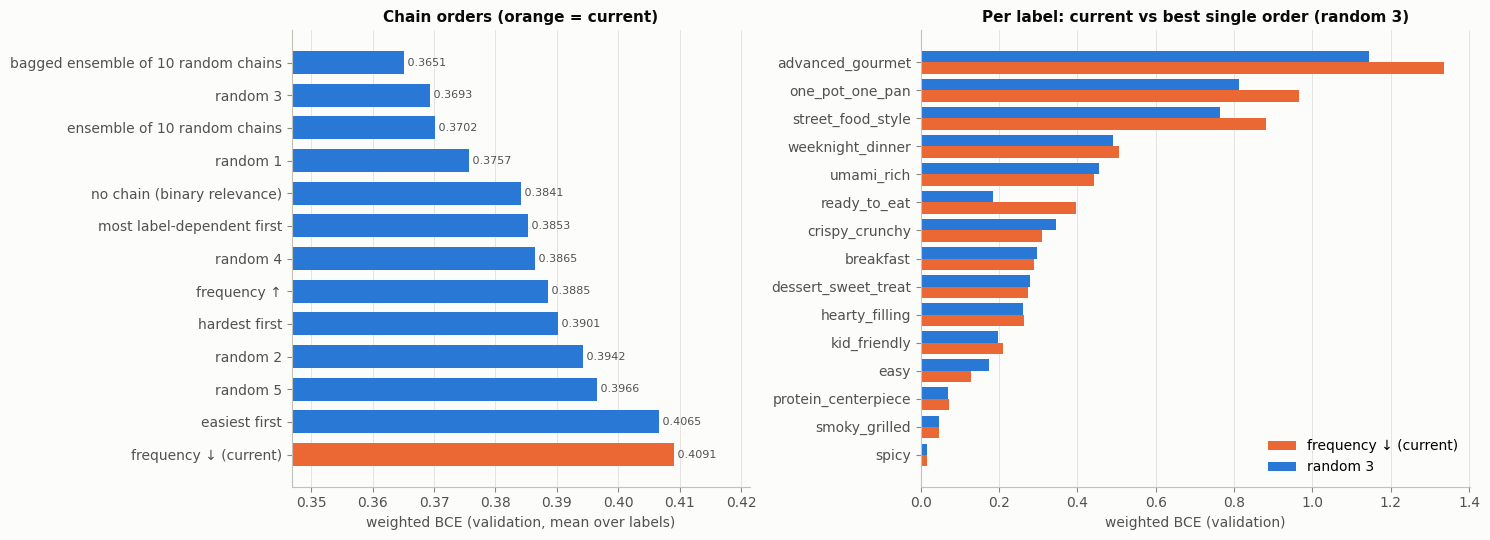

In [35]:
fig, (ax_bce, ax_label) = plt.subplots(1, 2, figsize=(15, 5.5), gridspec_kw={"width_ratios": [1, 1.2]})
viz_order = order_table["weighted BCE"].astype(float).sort_values(ascending=False)
ax_bce.barh(viz_order.index, viz_order.values, height=0.7,
            color=[SERIES[1] if name == "frequency ↓ (current)" else SERIES[0] for name in viz_order.index])
for y, v in enumerate(viz_order.values):
    ax_bce.text(v, y, f" {v:.4f}", va="center", fontsize=8, color=INK_2)
ax_bce.set_xlim(viz_order.min() * 0.95, viz_order.max() * 1.03)
ax_bce.grid(axis="y", visible=False)
ax_bce.set_xlabel("weighted BCE (validation, mean over labels)")
ax_bce.set_title("Chain orders (orange = current)")

# per-label loss: current order vs the best order, to see which labels gain
best_order_name = next(name for name in order_table.index if name in candidate_orders)
per_label = pd.DataFrame({
    "current": weighted_bce(Y_order_val, val_probas["frequency ↓ (current)"], order_pos_weight),
    best_order_name: weighted_bce(Y_order_val, val_probas[best_order_name], order_pos_weight),
}, index=CHAIN_LABELS).sort_values("current")
ys = np.arange(len(per_label))
ax_label.barh(ys - 0.2, per_label["current"], height=0.4, color=SERIES[1], label="frequency ↓ (current)")
ax_label.barh(ys + 0.2, per_label[best_order_name], height=0.4, color=SERIES[0], label=best_order_name)
ax_label.set_yticks(ys, per_label.index)
ax_label.grid(axis="y", visible=False)
ax_label.set_xlabel("weighted BCE (validation)")
ax_label.set_title(f"Per label: current vs best single order ({best_order_name})")
ax_label.legend(loc="lower right")
fig.tight_layout()
plt.show()


### Test split: current order vs best order vs ensembles

The best single order by validation weighted BCE and the ensembles of 10 random chains (plain and bagged), refit on all non-generic
train rows with the XGBoost gate, next to the current XGBoost model from above.


In [36]:
order_test_results = {"XGBoost | frequency ↓ (current)": model_results["XGBoost"]}
for name, orders, bootstrap in [(best_order_name, [candidate_orders[best_order_name]], False),
                                (f"ensemble of {N_ENSEMBLE_CHAINS} random chains", ensemble_orders, False),
                                (f"bagged ensemble of {N_ENSEMBLE_CHAINS} random chains", ensemble_orders, True)]:
    run_pipeline(f"XGBoost | {name}", "XGBoost", order_test_results, orders=orders, bootstrap=bootstrap)

order_comparison = show_comparison(order_test_results)
show_model_summary(order_test_results);


XGBoost | random 3: fit 10.8s  train loss 0.059  validation loss 0.611  accuracy 0.729  micro F1 0.878  macro F1 0.829
                     precision    recall  f1-score   support

   advanced_gourmet       0.69      0.60      0.64        42
          breakfast       0.96      0.90      0.93       130
     crispy_crunchy       0.82      0.83      0.83       172
dessert_sweet_treat       0.82      0.85      0.83        74
               easy       0.92      0.93      0.92       853
            generic       0.77      0.90      0.83       533
     hearty_filling       0.93      0.91      0.92       471
       kid_friendly       0.87      0.86      0.87       398
    one_pot_one_pan       0.79      0.76      0.78       106
protein_centerpiece       0.94      0.98      0.96       452
       ready_to_eat       0.87      0.88      0.88       359
      smoky_grilled       0.98      0.97      0.98       187
              spicy       0.67      0.40      0.50        15
  street_food_style       

XGBoost | ensemble of 10 random chains: fit 97.1s  train loss 0.059  validation loss 0.576  accuracy 0.727  micro F1 0.878  macro F1 0.829
                     precision    recall  f1-score   support

   advanced_gourmet       0.69      0.60      0.64        42
          breakfast       0.97      0.89      0.93       130
     crispy_crunchy       0.83      0.83      0.83       172
dessert_sweet_treat       0.79      0.84      0.82        74
               easy       0.91      0.93      0.92       853
            generic       0.77      0.90      0.83       533
     hearty_filling       0.92      0.91      0.92       471
       kid_friendly       0.87      0.86      0.86       398
    one_pot_one_pan       0.81      0.75      0.78       106
protein_centerpiece       0.94      0.98      0.96       452
       ready_to_eat       0.86      0.89      0.87       359
      smoky_grilled       0.98      0.97      0.98       187
              spicy       0.67      0.40      0.50        15
  stre

XGBoost | bagged ensemble of 10 random chains: fit 97.6s  train loss 0.103  validation loss 0.607  accuracy 0.723  micro F1 0.876  macro F1 0.823
                     precision    recall  f1-score   support

   advanced_gourmet       0.80      0.57      0.67        42
          breakfast       0.95      0.89      0.92       130
     crispy_crunchy       0.83      0.83      0.83       172
dessert_sweet_treat       0.80      0.80      0.80        74
               easy       0.90      0.93      0.91       853
            generic       0.77      0.90      0.83       533
     hearty_filling       0.92      0.90      0.91       471
       kid_friendly       0.88      0.86      0.87       398
    one_pot_one_pan       0.83      0.75      0.79       106
protein_centerpiece       0.94      0.98      0.96       452
       ready_to_eat       0.86      0.88      0.87       359
      smoky_grilled       0.98      0.96      0.97       187
              spicy       0.56      0.33      0.42        15

,micro F1,macro F1,samples F1,generic F1,macro precision,macro recall,validation loss,hamming loss,exact match,no label,generic + other,fit seconds
XGBoost | frequency ↓ (current),0.878,0.831,0.850,0.833,0.841,0.828,0.619,0.031,0.728,0,0,8.9
XGBoost | random 3,0.878,0.829,0.851,0.833,0.837,0.827,0.611,0.031,0.729,0,0,10.8
XGBoost | ensemble of 10 random chains,0.878,0.829,0.850,0.833,0.838,0.825,0.576,0.031,0.727,0,0,97.1
XGBoost | bagged ensemble of 10 random chains,0.876,0.823,0.848,0.833,0.842,0.811,0.607,0.032,0.723,0,0,97.6


,XGBoost | frequency ↓ (current),XGBoost | random 3,XGBoost | ensemble of 10 random chains,XGBoost | bagged ensemble of 10 random chains,support
easy,0.92,0.92,0.92,0.91,853
generic,0.83,0.83,0.83,0.83,533
hearty_filling,0.92,0.92,0.92,0.91,471
protein_centerpiece,0.96,0.96,0.96,0.96,452
kid_friendly,0.86,0.87,0.86,0.87,398
ready_to_eat,0.88,0.88,0.87,0.87,359
umami_rich,0.78,0.78,0.78,0.79,354
smoky_grilled,0.98,0.98,0.98,0.97,187
crispy_crunchy,0.82,0.83,0.83,0.83,172
breakfast,0.93,0.93,0.93,0.92,130


,train loss,validation loss,train accuracy,validation accuracy,validation label accuracy,macro precision,macro recall,macro F1
XGBoost | frequency ↓ (current),0.066,0.619,0.961,0.728,0.969,0.841,0.828,0.831
XGBoost | random 3,0.059,0.611,0.963,0.729,0.969,0.837,0.827,0.829
XGBoost | ensemble of 10 random chains,0.059,0.576,0.962,0.727,0.969,0.838,0.825,0.829
XGBoost | bagged ensemble of 10 random chains,0.103,0.607,0.941,0.723,0.968,0.842,0.811,0.823


## Save weights: XGBoost (own gate)

`model_artifacts/recipe_classifier_xgb/`, same layout as the logistic-regression model:
- `recipe_classifier.pt`: attention encoder `state_dict`, term vocabulary + frozen MiniLM term vectors, encoder config.
- `preprocessing.joblib`: nutrient train medians, nutrient scaler, UMAP (transform one row at a time), feature scaler.
- `xgb_models.joblib`: XGBoost generic gate and classifier chain. Each `BalancedXGB` is unwrapped to its fitted
  `XGBClassifier`, so loading needs only sklearn + xgboost, not this notebook.
- `config.json`: label order, chain order, settings and test metrics.

XGBoost can't run next to torch (see the XGBoost section), so the gate and chain are refit, saved, reloaded and used for
prediction in the torch-free worker. The last lines check that the reloaded files reproduce the XGBoost test predictions.


In [37]:
XGB_ARTIFACT_DIR = Path("model_artifacts/recipe_classifier_xgb")
XGB_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)


def fit_save_gated_xgb(X_fit, y_gate, X_specific, Y_specific, order, path):
    """Runs in the worker: fit the XGBoost gate + chain and save them with plain XGBClassifier links."""
    gate = MODEL_FACTORIES["XGBoost"]().fit(X_fit, y_gate)
    gated_chain = ClassifierChain(MODEL_FACTORIES["XGBoost"](), order=order, random_state=RANDOM_STATE).fit(X_specific, Y_specific)
    gated_chain.estimators_ = [link.model_ for link in gated_chain.estimators_]
    gated_chain.set_params(estimator=XGBClassifier())
    joblib.dump({"generic_gate": gate.model_, "chain": gated_chain}, path)


def predict_saved_xgb(path, X_rows):
    """Runs in the worker: load the saved gate + chain and predict."""
    saved = joblib.load(path)
    return predict_labels(X_rows, saved["generic_gate"], saved["chain"])


get_reusable_executor(max_workers=1).submit(
    fit_save_gated_xgb, X[train_idx], Y_np[train_idx, GENERIC], X[specific_train_idx], Y_specific,
    chain_order, XGB_ARTIFACT_DIR / "xgb_models.joblib",
).result()

torch.save({"state_dict": {k: v.detach().cpu() for k, v in encoder.state_dict().items()},
            "encoder_config": encoder_config, "vocab": vocab, "term_vectors": term_vectors},
           XGB_ARTIFACT_DIR / "recipe_classifier.pt")
joblib.dump({"nutrient_cols": NUTRIENT_COLS,
             "nutrient_medians": np.log1p(recipe_classes_df[NUTRIENT_COLS].clip(lower=0)).iloc[train_idx].median(),
             "nutrient_scaler": nutrient_scaler, "nutrient_umap": nutrient_umap, "feature_scaler": feature_scaler},
            XGB_ARTIFACT_DIR / "preprocessing.joblib")
xgb_saved_pred = model_results["XGBoost"]["pred"]
(XGB_ARTIFACT_DIR / "config.json").write_text(json.dumps({
    "model": "xgboost", "nutrient_reduction": "umap", "gate": "xgboost",
    "label_cols": LABEL_COLS, "dropped_labels": DROPPED_LABELS, "gate_label": "generic",
    "chain_labels": CHAIN_LABELS, "chain_order": chain_order.tolist(),
    "xgb_params": MODEL_FACTORIES["XGBoost"]().get_params(),
    "term_model": TERM_MODEL, "term_revision": TERM_REVISION, "random_state": RANDOM_STATE, "test_size": TEST_SIZE,
    "encoder_epochs": ENCODER_EPOCHS, "encoder_lr": ENCODER_LR, "nutrient_umap_components": NUTRIENT_UMAP_COMPONENTS,
    "umap_transform": "one row at a time",
    "test_metrics": {"micro_f1": f1_score(Y_true, xgb_saved_pred, average="micro"),
                     "macro_f1": f1_score(Y_true, xgb_saved_pred, average="macro"),
                     "hamming_loss": hamming_loss(Y_true, xgb_saved_pred),
                     "exact_match": accuracy_score(Y_true, xgb_saved_pred)},
}, indent=2))

# reload every file and check the saved pipeline reproduces the XGBoost test predictions
saved = torch.load(XGB_ARTIFACT_DIR / "recipe_classifier.pt", weights_only=False)
reloaded = ItemAttentionEncoder(saved["term_vectors"], saved["encoder_config"]["n_labels"])
reloaded.load_state_dict(saved["state_dict"])
reloaded.eval()
prep = joblib.load(XGB_ARTIFACT_DIR / "preprocessing.joblib")
with torch.no_grad():
    emb = reloaded.embed(torch.tensor(term_ids[test_idx]), torch.tensor(type_ids[test_idx])).numpy()
nut = np.log1p(recipe_classes_df[NUTRIENT_COLS].clip(lower=0)).iloc[test_idx].fillna(prep["nutrient_medians"]).to_numpy()
nut_umap = umap_transform(prep["nutrient_umap"], prep["nutrient_scaler"].transform(nut))
X_re = prep["feature_scaler"].transform(np.hstack([emb, nut_umap]))
xgb_reloaded_pred = get_reusable_executor(max_workers=1).submit(
    predict_saved_xgb, XGB_ARTIFACT_DIR / "xgb_models.joblib", X_re).result()
assert (xgb_reloaded_pred == xgb_saved_pred).all()
print("saved to", XGB_ARTIFACT_DIR, sorted(p.name for p in XGB_ARTIFACT_DIR.iterdir()))


saved to model_artifacts/recipe_classifier_xgb ['config.json', 'preprocessing.joblib', 'recipe_classifier.pt', 'xgb_models.joblib']


## Save the best models: precision and recall

Every pipeline trained above (six models × own / shared LR gate, plus the XGBoost chain-order
variants) ranked by **macro precision** and **macro recall** on the validation split (macro, so every label counts
the same, as with macro F1). The best model for each is refit from its settings (every model is deterministic), saved
and reloaded to check it reproduces its validation predictions. If one model is best at both, it is saved once.

`model_artifacts/recipe_classifier_best_<metric>/`:
- `recipe_classifier.pt`: attention encoder, term vocabulary + frozen MiniLM term vectors, encoder config.
- `preprocessing.joblib`: nutrient medians and scaler, the nutrient UMAP (transform one row at a time), feature scaler.
- `models.joblib`: `generic_gate` and `chains` (a list; with several chains, average their probabilities).
  XGBoost models are saved as plain `XGBClassifier`s.
- `config.json`: model settings, label order and validation metrics.

Caveat: the pick uses the same split the scores are reported on, since there is no other held-out split.


In [38]:
all_results = ({f"{n} | own gate": r for n, r in model_results.items()}
               | {f"{n} | LR gate": r for n, r in lr_gate_results.items()}
               | {f"{n} | own gate": r for n, r in order_test_results.items() if n != "XGBoost | frequency ↓ (current)"})
leaderboard = pd.DataFrame({name: summary_scores(r) for name, r in all_results.items()}).T
best_models = {metric: leaderboard[f"macro {metric}"].idxmax() for metric in ["precision", "recall"]}

display(leaderboard.sort_values("macro F1", ascending=False).style.format("{:.3f}")
        .background_gradient(cmap="Greens", subset=["macro precision", "macro recall", "macro F1"])
        .background_gradient(cmap="Greens_r", subset=["validation loss"]))
for metric, name in best_models.items():
    print(f"best macro {metric}: {name}  ({leaderboard.loc[name, f'macro {metric}']:.3f})")


,train loss,validation loss,train accuracy,validation accuracy,validation label accuracy,macro precision,macro recall,macro F1
XGBoost | own gate,0.066,0.619,0.961,0.728,0.969,0.841,0.828,0.831
XGBoost | random 3 | own gate,0.059,0.611,0.963,0.729,0.969,0.837,0.827,0.829
XGBoost | ensemble of 10 random chains | own gate,0.059,0.576,0.962,0.727,0.969,0.838,0.825,0.829
Random Forest | own gate,0.131,0.618,0.959,0.710,0.968,0.869,0.797,0.827
XGBoost | bagged ensemble of 10 random chains | own gate,0.103,0.607,0.941,0.723,0.968,0.842,0.811,0.823
KNN | own gate,0.003,0.912,0.998,0.688,0.965,0.859,0.795,0.821
XGBoost | LR gate,0.188,0.685,0.878,0.701,0.964,0.842,0.807,0.821
Random Forest | LR gate,0.255,0.709,0.866,0.687,0.963,0.869,0.767,0.807
KNN | LR gate,0.171,0.964,0.893,0.662,0.960,0.862,0.769,0.805
SVM | own gate,0.269,0.587,0.693,0.645,0.959,0.758,0.864,0.803


best macro precision: Random Forest | LR gate  (0.869)
best macro recall: SVM | own gate  (0.864)


In [39]:
def fit_save_pipeline(model_name, X_fit, y_gate, X_specific, Y_specific, orders, gate, path, bootstrap=False):
    """Fit gate + chain(s) and save them; XGBoost models are unwrapped to plain XGBClassifier."""
    gate, chains = fit_pipeline(model_name, X_fit, y_gate, X_specific, Y_specific, orders, gate, bootstrap)
    if model_name == "XGBoost":
        gate = gate.model_ if isinstance(gate, BalancedXGB) else gate
        for chain in chains:
            chain.estimators_ = [link.model_ for link in chain.estimators_]
            chain.set_params(estimator=XGBClassifier())
    joblib.dump({"generic_gate": gate, "chains": chains}, path)


def predict_saved_pipeline(path, X_rows):
    """Runs in the worker (XGBoost can't run next to torch): load gate + chains and predict."""
    saved = joblib.load(path)
    chains = saved["chains"]
    return predict_labels(X_rows, saved["generic_gate"], chains[0] if len(chains) == 1 else EnsembleChain(chains))


def save_best_pipeline(name, out_dir):
    r, spec = all_results[name], all_results[name]["spec"]
    Xf = X
    out_dir.mkdir(parents=True, exist_ok=True)
    fit_args = (spec["model"], Xf[train_idx], Y_np[train_idx, GENERIC], Xf[specific_train_idx], Y_specific,
                spec["orders"], None if spec["gate"] == "own" else generic_gate, out_dir / "models.joblib",
                spec["bootstrap"])
    if spec["model"] == "XGBoost":
        executor.submit(fit_save_pipeline, *fit_args).result()
    else:
        fit_save_pipeline(*fit_args)

    torch.save({"state_dict": {k: v.detach().cpu() for k, v in encoder.state_dict().items()},
                "encoder_config": encoder_config, "vocab": vocab, "term_vectors": term_vectors},
               out_dir / "recipe_classifier.pt")
    joblib.dump({"nutrient_cols": NUTRIENT_COLS,
                 "nutrient_medians": np.log1p(recipe_classes_df[NUTRIENT_COLS].clip(lower=0)).iloc[train_idx].median(),
                 "nutrient_scaler": nutrient_scaler, "nutrient_umap": nutrient_umap, "feature_scaler": feature_scaler},
                out_dir / "preprocessing.joblib")
    (out_dir / "config.json").write_text(json.dumps({
        "name": name, "model": spec["model"], "gate": spec["gate"],
        "chain_orders": [o.tolist() for o in spec["orders"]], "l2_strength": L2_STRENGTH.get(spec["model"]), "bagged_chains": spec["bootstrap"],
        "umap_transform": "one row at a time",
        "label_cols": LABEL_COLS, "dropped_labels": DROPPED_LABELS, "gate_label": "generic", "chain_labels": CHAIN_LABELS,
        "term_model": TERM_MODEL, "term_revision": TERM_REVISION, "random_state": RANDOM_STATE, "test_size": TEST_SIZE,
        "validation_metrics": {k: float(v) for k, v in summary_scores(r).items()},
    }, indent=2))

    # reload every file and check the saved pipeline reproduces the validation predictions
    saved = torch.load(out_dir / "recipe_classifier.pt", weights_only=False)
    reloaded = ItemAttentionEncoder(saved["term_vectors"], saved["encoder_config"]["n_labels"])
    reloaded.load_state_dict(saved["state_dict"])
    reloaded.eval()
    prep = joblib.load(out_dir / "preprocessing.joblib")
    with torch.no_grad():
        emb = reloaded.embed(torch.tensor(term_ids[test_idx]), torch.tensor(type_ids[test_idx])).numpy()
    nut = np.log1p(recipe_classes_df[NUTRIENT_COLS].clip(lower=0)).iloc[test_idx].fillna(prep["nutrient_medians"]).to_numpy()
    nut = prep["nutrient_scaler"].transform(nut)
    nut = umap_transform(prep["nutrient_umap"], nut)
    X_re = prep["feature_scaler"].transform(np.hstack([emb, nut]))
    reloaded_pred = executor.submit(predict_saved_pipeline, out_dir / "models.joblib", X_re).result()
    assert (reloaded_pred == r["pred"]).all()
    print(f"saved {name} to {out_dir}", sorted(p.name for p in out_dir.iterdir()))


if best_models["precision"] == best_models["recall"]:
    save_best_pipeline(best_models["precision"], Path("model_artifacts/recipe_classifier_best_precision_recall"))
else:
    for metric, name in best_models.items():
        save_best_pipeline(name, Path(f"model_artifacts/recipe_classifier_best_{metric}"))


saved Random Forest | LR gate to model_artifacts/recipe_classifier_best_precision ['config.json', 'models.joblib', 'preprocessing.joblib', 'recipe_classifier.pt']


saved SVM | own gate to model_artifacts/recipe_classifier_best_recall ['config.json', 'models.joblib', 'preprocessing.joblib', 'recipe_classifier.pt']
